<a href="https://colab.research.google.com/github/Kimia998/Forecasting-of-3-Month-Gold-Returns/blob/main/Goldprice_project_daily_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Start

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 1. LOAD FILES
gold = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Gold prices _ daily.csv")
oil = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Crude Oil Prices Brent - Europe.csv")
usd = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Nominal Broad U.S. Dollar Index.csv")
inflation = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Consumer Price Index.csv")

# =========================================================
# 2. RENAME COLUMNS
# Gold file from Stooq: Date, Open, High, Low, Close
# We use Close as the main gold price
# =========================================================
gold = gold.rename(columns={
    "Date": "date",
    "Open": "gold_open",
    "High": "gold_high",
    "Low": "gold_low",
    "Close": "gold_price"
})

oil = oil.rename(columns={
    "observation_date": "date",
    "DCOILBRENTEU": "oil_price"
})

usd = usd.rename(columns={
    "observation_date": "date",
    "DTWEXBGS": "usd_index"
})

inflation = inflation.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})

# =========================================================
# 3. CONVERT DATES
# =========================================================
gold["date"] = pd.to_datetime(gold["date"], errors="coerce")
oil["date"] = pd.to_datetime(oil["date"], errors="coerce")
usd["date"] = pd.to_datetime(usd["date"], errors="coerce")
inflation["date"] = pd.to_datetime(inflation["date"], errors="coerce")

# =========================================================
# 4. CLEAN NUMERIC COLUMNS
# Handles commas, spaces, and FRED missing values like "."
# =========================================================
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace(" ", "", regex=False)
              .replace(".", np.nan),
        errors="coerce"
    )

gold["gold_open"] = clean_numeric(gold["gold_open"])
gold["gold_high"] = clean_numeric(gold["gold_high"])
gold["gold_low"] = clean_numeric(gold["gold_low"])
gold["gold_price"] = clean_numeric(gold["gold_price"])

oil["oil_price"] = clean_numeric(oil["oil_price"])
usd["usd_index"] = clean_numeric(usd["usd_index"])
inflation["cpi"] = clean_numeric(inflation["cpi"])

# =========================================================
# 5. FILTER FROM 2006 ONWARD
# =========================================================
gold = gold[gold["date"] >= "2006-01-01"].copy()
oil = oil[oil["date"] >= "2006-01-01"].copy()
usd = usd[usd["date"] >= "2006-01-01"].copy()
inflation = inflation[inflation["date"] >= "2006-01-01"].copy()

# =========================================================
# 6. SORT ASCENDING AND DROP DUPLICATES
# Stooq often comes newest first
# =========================================================
gold = gold.sort_values("date").drop_duplicates("date")
oil = oil.sort_values("date").drop_duplicates("date")
usd = usd.sort_values("date").drop_duplicates("date")
inflation = inflation.sort_values("date").drop_duplicates("date")

# =========================================================
# 7. CHECK DATE RANGES
# =========================================================
print("Gold:", gold["date"].min(), "to", gold["date"].max())
print("Oil:", oil["date"].min(), "to", oil["date"].max())
print("USD:", usd["date"].min(), "to", usd["date"].max())
print("CPI:", inflation["date"].min(), "to", inflation["date"].max())

# =========================================================
# 8. COMMON PREDICTOR END DATE
# IMPORTANT:
# Gold may go further, keep it for future target creation
# But predictors define the last usable input date
# =========================================================
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max()
)

print("Common predictor end date:", common_predictor_end)

# Trim only predictors to common predictor end
oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()

# Keep gold longer, because future gold prices are needed for target construction

# =========================================================
# 9. MERGE DAILY DATA IN PANDAS
# Base calendar = gold trading dates
# direction='backward' means only use information known up to that date
# =========================================================
df_merged = gold[["date", "gold_open", "gold_high", "gold_low", "gold_price"]].copy()

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    oil[["date", "oil_price"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

# Fill missing predictor values with last known past value
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi"]].isna().sum())

# =========================================================
# 10. GEOPOLITICAL VARIABLES
# =========================================================
df_merged["geopolitical_risk_level"] = 0
df_merged["middle_east_level"] = 0

# Global geopolitical risk
df_merged.loc[
    (df_merged["date"] >= "2014-03-01") & (df_merged["date"] < "2022-02-01"),
    "geopolitical_risk_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2022-02-01",
    "geopolitical_risk_level"
] = 2

# Middle East risk
df_merged.loc[
    (df_merged["date"] >= "2011-01-01") & (df_merged["date"] <= "2012-12-31"),
    "middle_east_level"
] = 1

df_merged.loc[
    (df_merged["date"] >= "2023-10-01") & (df_merged["date"] < "2024-04-01"),
    "middle_east_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2024-04-01",
    "middle_east_level"
] = 2

print("\nMissing values after merge:")
print(df_merged.isna().sum())

# =========================================================
# 11. DAILY FEATURE ENGINEERING
# Approximation:
# 21 trading days ≈ 1 month
# 63 trading days ≈ 3 months
# 126 trading days ≈ 6 months
# =========================================================
df_model = df_merged.sort_values("date").copy()

# Gold daily return
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

# Gold momentum
df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

# Gold moving averages and trend position
df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()
df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

# Gold volatility
df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

# OHLC-based gold features
df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Macro changes
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

# Macro moving averages
df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# =========================================================
# 12. CREATE 3-MONTH FUTURE TARGET
# For each row:
# target_return_3m = future gold price / current gold price - 1
# We use the first available trading day on or after t + 3 months
# =========================================================
df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

# =========================================================
# 13. KEEP ONLY ROWS WHERE PREDICTORS WERE STILL AVAILABLE
# Gold can extend further for target creation,
# but model input rows must not go beyond predictor end date
# =========================================================
df_model = df_model[df_model["date"] <= common_predictor_end].copy()

# =========================================================
# 14. FEATURE LIST
# =========================================================
feature_cols = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 15. DROP ROWS WITH MISSING FEATURES OR TARGET
# =========================================================
df_model = df_model.dropna(subset=feature_cols + ["target_return_3m"]).copy()

# =========================================================
# 16. FINAL X AND y
# =========================================================
X = df_model[feature_cols]
y = df_model["target_return_3m"]

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nShapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# =========================================================
# 17. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# =========================================================
# 18. NAIVE BASELINE
# =========================================================
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline, Train Mean", y_test, baseline_pred))

# =========================================================
# 19. LINEAR REGRESSION
# =========================================================
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lin))

lin_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lin_model.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

print("\nLinear Regression Coefficients")
print(lin_coef_df)

# =========================================================
# 20. RIDGE REGRESSION
# =========================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))

ridge_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

print("\nRidge Regression Coefficients")
print(ridge_coef_df)

# =========================================================
# 21. RANDOM FOREST
# =========================================================
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model("Random Forest Regressor", y_test, y_pred_rf))

rf_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nRandom Forest Feature Importance")
print(rf_importance_df)

# =========================================================
# 22. MODEL COMPARISON
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nModel Comparison")
print(results_df)

# =========================================================
# 23. DEBUG TARGET ALIGNMENT
# =========================================================
print("\nLast rows of date, expected_future_3m, future_date_actual, gold_price, future_gold_price_3m, target_return_3m")
print(
    df_model[
        ["date", "expected_future_3m", "future_date_actual", "gold_price", "future_gold_price_3m", "target_return_3m"]
    ].tail(10)
)

# Final dataframe preview
df_model.head()

Gold: 2006-03-01 00:00:00 to 2026-04-10 00:00:00
Oil: 2006-01-03 00:00:00 to 2026-03-31 00:00:00
USD: 2006-01-02 00:00:00 to 2026-03-31 00:00:00
CPI: 2006-01-01 00:00:00 to 2026-02-01 00:00:00
Common predictor end date: 2026-02-01 00:00:00

Missing values after forward fill:
oil_price    0
usd_index    0
cpi          0
dtype: int64

Missing values after merge:
date                       0
gold_open                  0
gold_high                  0
gold_low                   0
gold_price                 0
oil_price                  0
usd_index                  0
cpi                        0
geopolitical_risk_level    0
middle_east_level          0
dtype: int64

Shapes:
X_train shape: (3999, 21)
X_test shape: (1000, 21)
y_train shape: (3999,)
y_test shape: (1000,)

Naive Baseline, Train Mean
MAE:  0.0769
RMSE: 0.0976
R2:   -0.2598

Linear Regression
MAE:  0.1339
RMSE: 0.1515
R2:   -2.0345

Linear Regression Coefficients
                    Feature  Coefficient
5              gold_vol_21d  

,date,gold_open,gold_high,gold_low,gold_price,oil_price,usd_index,cpi,geopolitical_risk_level,middle_east_level,...,oil_change_63d,usd_change_63d,cpi_change_63d,oil_ma21,usd_ma21,cpi_ma21,expected_future_3m,future_date_actual,future_gold_price_3m,target_return_3m
126,2006-08-28,622.40,623.70,612.6,614.10,69.44,97.8467,203.8,0,0,...,0.027675,0.000779,0.012419,74.153810,97.734200,203.757143,2006-11-28,2006-11-28,638.20,0.039244
127,2006-08-29,613.15,617.60,607.1,611.70,67.01,97.7748,203.8,0,0,...,-0.025593,0.000023,0.009911,73.785238,97.723495,203.800000,2006-11-29,2006-11-29,635.70,0.039235
128,2006-08-30,614.00,620.70,612.2,617.40,67.15,97.5792,203.8,0,0,...,-0.018562,0.000254,0.009911,73.345238,97.695290,203.800000,2006-11-30,2006-11-30,646.25,0.046728
129,2006-08-31,618.10,626.30,617.6,625.10,67.66,97.6440,203.8,0,0,...,-0.021264,0.002834,0.009911,72.870476,97.681043,203.800000,2006-11-30,2006-11-30,646.25,0.033835
130,2006-09-01,625.95,627.45,619.2,624.33,70.49,97.5084,202.8,0,0,...,0.032821,-0.006485,0.004955,72.594762,97.654329,203.752381,2006-12-01,2006-12-01,645.75,0.034309


In [ ]:
nan_counts = df_model[feature_cols + ["target_return_3m"]].isna().sum().sort_values(ascending=False)
print(nan_counts)

gold_mom_21d               0
gold_mom_63d               0
gold_mom_126d              0
gold_vs_ma21               0
gold_vs_ma63               0
gold_vol_21d               0
gold_vol_63d               0
gold_intraday_return       0
gold_range_pct             0
oil_change_21d             0
usd_change_21d             0
cpi_change_21d             0
oil_change_63d             0
usd_change_63d             0
cpi_change_63d             0
oil_ma21                   0
usd_ma21                   0
cpi                        0
cpi_ma21                   0
geopolitical_risk_level    0
middle_east_level          0
target_return_3m           0
dtype: int64


In [ ]:
gold

,date,gold_open,gold_high,gold_low,gold_price
0,2006-03-01,563.00,566.500,559.800,563.300
1,2006-03-02,562.00,569.930,561.200,569.500
2,2006-03-03,568.90,570.200,563.700,565.900
3,2006-03-06,564.90,568.100,551.800,554.350
4,2006-03-07,553.90,558.000,548.400,552.400
...,...,...,...,...,...
5185,2026-04-06,4632.83,4706.125,4601.215,4650.685
5186,2026-04-07,4649.31,4716.695,4608.295,4705.655
5187,2026-04-08,4719.27,4857.655,4700.515,4719.285
5188,2026-04-09,4725.42,4800.885,4698.945,4765.645


In [ ]:
oil

,date,oil_price
0,2006-01-03,61.51
1,2006-01-04,61.25
2,2006-01-05,61.68
3,2006-01-06,62.43
4,2006-01-09,62.51
...,...,...
5234,2026-01-26,67.70
5235,2026-01-27,70.28
5236,2026-01-28,70.90
5237,2026-01-29,71.00


In [ ]:
usd

,date,usd_index
0,2006-01-02,101.4155
1,2006-01-03,100.7558
2,2006-01-04,100.2288
3,2006-01-05,100.2992
4,2006-01-06,100.0241
...,...,...
5235,2026-01-26,118.0525
5236,2026-01-27,117.4523
5237,2026-01-28,117.5117
5238,2026-01-29,117.4396


In [ ]:
inflation

,date,cpi
0,2006-01-01,199.300
1,2006-02-01,199.400
2,2006-03-01,199.700
3,2006-04-01,200.700
4,2006-05-01,201.300
...,...,...
237,2025-10-01,NaN
238,2025-11-01,325.063
239,2025-12-01,326.031
240,2026-01-01,326.588


# vergleich

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 1. LOAD FILES
gold = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Gold prices _ daily.csv")
oil = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Crude Oil Prices Brent - Europe.csv")
usd = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Nominal Broad U.S. Dollar Index.csv")
inflation = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Consumer Price Index.csv")
real_yield = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Market Yield on U.S. Treasury Securities_inflation.csv")

# =========================================================
# 2. RENAME COLUMNS
# Gold file from Stooq: Date, Open, High, Low, Close
# We use Close as the main gold price
# =========================================================
gold = gold.rename(columns={
    "Date": "date",
    "Open": "gold_open",
    "High": "gold_high",
    "Low": "gold_low",
    "Close": "gold_price"
})

oil = oil.rename(columns={
    "observation_date": "date",
    "DCOILBRENTEU": "oil_price"
})

usd = usd.rename(columns={
    "observation_date": "date",
    "DTWEXBGS": "usd_index"
})

inflation = inflation.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})

# =========================================================
# 3. CONVERT DATES
# =========================================================
gold["date"] = pd.to_datetime(gold["date"], errors="coerce")
oil["date"] = pd.to_datetime(oil["date"], errors="coerce")
usd["date"] = pd.to_datetime(usd["date"], errors="coerce")
inflation["date"] = pd.to_datetime(inflation["date"], errors="coerce")

# =========================================================
# 4. CLEAN NUMERIC COLUMNS
# Handles commas, spaces, and FRED missing values like "."
# =========================================================
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace(" ", "", regex=False)
              .replace(".", np.nan),
        errors="coerce"
    )

gold["gold_open"] = clean_numeric(gold["gold_open"])
gold["gold_high"] = clean_numeric(gold["gold_high"])
gold["gold_low"] = clean_numeric(gold["gold_low"])
gold["gold_price"] = clean_numeric(gold["gold_price"])

oil["oil_price"] = clean_numeric(oil["oil_price"])
usd["usd_index"] = clean_numeric(usd["usd_index"])
inflation["cpi"] = clean_numeric(inflation["cpi"])

# =========================================================
# 5. FILTER FROM 2006 ONWARD
# =========================================================
gold = gold[gold["date"] >= "2006-01-01"].copy()
oil = oil[oil["date"] >= "2006-01-01"].copy()
usd = usd[usd["date"] >= "2006-01-01"].copy()
inflation = inflation[inflation["date"] >= "2006-01-01"].copy()

# =========================================================
# 6. SORT ASCENDING AND DROP DUPLICATES
# Stooq often comes newest first
# =========================================================
gold = gold.sort_values("date").drop_duplicates("date")
oil = oil.sort_values("date").drop_duplicates("date")
usd = usd.sort_values("date").drop_duplicates("date")
inflation = inflation.sort_values("date").drop_duplicates("date")

# =========================================================
# 7. CHECK DATE RANGES
# =========================================================
print("Gold:", gold["date"].min(), "to", gold["date"].max())
print("Oil:", oil["date"].min(), "to", oil["date"].max())
print("USD:", usd["date"].min(), "to", usd["date"].max())
print("CPI:", inflation["date"].min(), "to", inflation["date"].max())

# =========================================================
# 8. COMMON PREDICTOR END DATE
# IMPORTANT:
# Gold may go further, keep it for future target creation
# But predictors define the last usable input date
# =========================================================
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max()
)

print("Common predictor end date:", common_predictor_end)

# Trim only predictors to common predictor end
oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()

# Keep gold longer, because future gold prices are needed for target construction

# =========================================================
# 9. MERGE DAILY DATA IN PANDAS
# Base calendar = gold trading dates
# direction='backward' means only use information known up to that date
# =========================================================
df_merged = gold[["date", "gold_open", "gold_high", "gold_low", "gold_price"]].copy()

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    oil[["date", "oil_price"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

# Fill missing predictor values with last known past value
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi"]].isna().sum())

# =========================================================
# 10. GEOPOLITICAL VARIABLES
# =========================================================
df_merged["geopolitical_risk_level"] = 0
df_merged["middle_east_level"] = 0

# Global geopolitical risk
df_merged.loc[
    (df_merged["date"] >= "2014-03-01") & (df_merged["date"] < "2022-02-01"),
    "geopolitical_risk_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2022-02-01",
    "geopolitical_risk_level"
] = 2

# Middle East risk
df_merged.loc[
    (df_merged["date"] >= "2011-01-01") & (df_merged["date"] <= "2012-12-31"),
    "middle_east_level"
] = 1

df_merged.loc[
    (df_merged["date"] >= "2023-10-01") & (df_merged["date"] < "2024-04-01"),
    "middle_east_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2024-04-01",
    "middle_east_level"
] = 2

print("\nMissing values after merge:")
print(df_merged.isna().sum())

# =========================================================
# 11. DAILY FEATURE ENGINEERING
# Approximation:
# 21 trading days ≈ 1 month
# 63 trading days ≈ 3 months
# 126 trading days ≈ 6 months
# =========================================================
df_model = df_merged.sort_values("date").copy()

# Gold daily return
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

# Gold momentum
df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

# Gold moving averages and trend position
df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()
df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

# Gold volatility
df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

# OHLC-based gold features
df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Macro changes
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

# Macro moving averages
df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# =========================================================
# 12. CREATE 3-MONTH FUTURE TARGET
# For each row:
# target_return_3m = future gold price / current gold price - 1
# We use the first available trading day on or after t + 3 months
# =========================================================
df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

# =========================================================
# 13. KEEP ONLY ROWS WHERE PREDICTORS WERE STILL AVAILABLE
# Gold can extend further for target creation,
# but model input rows must not go beyond predictor end date
# =========================================================
df_model = df_model[df_model["date"] <= common_predictor_end].copy()

# =========================================================
# 14. FEATURE LIST
# =========================================================
feature_cols = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 15. DROP ROWS WITH MISSING FEATURES OR TARGET
# =========================================================
df_model = df_model.dropna(subset=feature_cols + ["target_return_3m"]).copy()

# =========================================================
# 16. FINAL X AND y
# =========================================================
X = df_model[feature_cols]
y = df_model["target_return_3m"]

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nShapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# =========================================================
# 17. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# =========================================================
# 18. NAIVE BASELINE
# =========================================================
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline, Train Mean", y_test, baseline_pred))

# =========================================================
# 19. LINEAR REGRESSION
# =========================================================
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lin))

lin_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lin_model.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

print("\nLinear Regression Coefficients")
print(lin_coef_df)

# =========================================================
# 20. RIDGE REGRESSION
# =========================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))

ridge_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

print("\nRidge Regression Coefficients")
print(ridge_coef_df)

# =========================================================
# 21. RANDOM FOREST
# =========================================================
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model("Random Forest Regressor", y_test, y_pred_rf))

rf_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nRandom Forest Feature Importance")
print(rf_importance_df)

# =========================================================
# 22. MODEL COMPARISON
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nModel Comparison")
print(results_df)

# =========================================================
# 23. DEBUG TARGET ALIGNMENT
# =========================================================
print("\nLast rows of date, expected_future_3m, future_date_actual, gold_price, future_gold_price_3m, target_return_3m")
print(
    df_model[
        ["date", "expected_future_3m", "future_date_actual", "gold_price", "future_gold_price_3m", "target_return_3m"]
    ].tail(10)
)

# Final dataframe preview
df_model.head()

Gold: 2006-03-01 00:00:00 to 2026-04-10 00:00:00
Oil: 2006-01-03 00:00:00 to 2026-03-31 00:00:00
USD: 2006-01-02 00:00:00 to 2026-03-31 00:00:00
CPI: 2006-01-01 00:00:00 to 2026-02-01 00:00:00
Common predictor end date: 2026-02-01 00:00:00

Missing values after forward fill:
oil_price    0
usd_index    0
cpi          0
dtype: int64

Missing values after merge:
date                       0
gold_open                  0
gold_high                  0
gold_low                   0
gold_price                 0
oil_price                  0
usd_index                  0
cpi                        0
geopolitical_risk_level    0
middle_east_level          0
dtype: int64

Shapes:
X_train shape: (3999, 21)
X_test shape: (1000, 21)
y_train shape: (3999,)
y_test shape: (1000,)

Naive Baseline, Train Mean
MAE:  0.0769
RMSE: 0.0976
R2:   -0.2598

Linear Regression
MAE:  0.1339
RMSE: 0.1515
R2:   -2.0345

Linear Regression Coefficients
                    Feature  Coefficient
5              gold_vol_21d  

,date,gold_open,gold_high,gold_low,gold_price,oil_price,usd_index,cpi,geopolitical_risk_level,middle_east_level,...,oil_change_63d,usd_change_63d,cpi_change_63d,oil_ma21,usd_ma21,cpi_ma21,expected_future_3m,future_date_actual,future_gold_price_3m,target_return_3m
126,2006-08-28,622.40,623.70,612.6,614.10,69.44,97.8467,203.8,0,0,...,0.027675,0.000779,0.012419,74.153810,97.734200,203.757143,2006-11-28,2006-11-28,638.20,0.039244
127,2006-08-29,613.15,617.60,607.1,611.70,67.01,97.7748,203.8,0,0,...,-0.025593,0.000023,0.009911,73.785238,97.723495,203.800000,2006-11-29,2006-11-29,635.70,0.039235
128,2006-08-30,614.00,620.70,612.2,617.40,67.15,97.5792,203.8,0,0,...,-0.018562,0.000254,0.009911,73.345238,97.695290,203.800000,2006-11-30,2006-11-30,646.25,0.046728
129,2006-08-31,618.10,626.30,617.6,625.10,67.66,97.6440,203.8,0,0,...,-0.021264,0.002834,0.009911,72.870476,97.681043,203.800000,2006-11-30,2006-11-30,646.25,0.033835
130,2006-09-01,625.95,627.45,619.2,624.33,70.49,97.5084,202.8,0,0,...,0.032821,-0.006485,0.004955,72.594762,97.654329,203.752381,2006-12-01,2006-12-01,645.75,0.034309


# reducing features

In [ ]:
feature_cols_full=[
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]


feature_cols_reduced = [
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "middle_east_level"
]

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

comparison_results = []

# -----------------------------
# FULL FEATURE MODEL
# -----------------------------
X_full = df_model[feature_cols_full]
y_full = df_model["target_return_3m"]

split_index_full = int(len(df_model) * 0.8)

X_train_full = X_full.iloc[:split_index_full]
X_test_full = X_full.iloc[split_index_full:]
y_train_full = y_full.iloc[:split_index_full]
y_test_full = y_full.iloc[split_index_full:]

rf_full = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X_train_full, y_train_full)
y_pred_full = rf_full.predict(X_test_full)

comparison_results.append(
    evaluate_model("Random Forest, Full Features", y_test_full, y_pred_full)
)

# -----------------------------
# REDUCED FEATURE MODEL
# -----------------------------
X_reduced = df_model[feature_cols_reduced]
y_reduced = df_model["target_return_3m"]

split_index_reduced = int(len(df_model) * 0.8)

X_train_reduced = X_reduced.iloc[:split_index_reduced]
X_test_reduced = X_reduced.iloc[split_index_reduced:]
y_train_reduced = y_reduced.iloc[:split_index_reduced]
y_test_reduced = y_reduced.iloc[split_index_reduced:]

rf_reduced = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_reduced.fit(X_train_reduced, y_train_reduced)
y_pred_reduced = rf_reduced.predict(X_test_reduced)

comparison_results.append(
    evaluate_model("Random Forest, Reduced Features", y_test_reduced, y_pred_reduced)
)

# -----------------------------
# COMPARE
# -----------------------------
comparison_df = pd.DataFrame(comparison_results).sort_values("RMSE")
print(comparison_df)

comparison_df

                             Model       MAE      RMSE        R2
0     Random Forest, Full Features  0.073688  0.092767 -0.137968
1  Random Forest, Reduced Features  0.074293  0.093687 -0.160653


,Model,MAE,RMSE,R2
0,"Random Forest, Full Features",0.073688,0.092767,-0.137968
1,"Random Forest, Reduced Features",0.074293,0.093687,-0.160653


In [ ]:
reduced_importance_df = pd.DataFrame({
    "Feature": feature_cols_reduced,
    "Importance": rf_reduced.feature_importances_
}).sort_values("Importance", ascending=False)

print(reduced_importance_df)

              Feature  Importance
14           cpi_ma21    0.191862
12           usd_ma21    0.168156
5        gold_vol_63d    0.113429
11           oil_ma21    0.105439
10     cpi_change_63d    0.090448
13                cpi    0.056043
7      cpi_change_21d    0.048465
3        gold_vs_ma63    0.042033
1       gold_mom_126d    0.041987
9      usd_change_63d    0.041279
0        gold_mom_63d    0.039536
4        gold_vol_21d    0.017501
2        gold_vs_ma21    0.015342
15  middle_east_level    0.012174
6      oil_change_21d    0.009299
8      oil_change_63d    0.007007


In [ ]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# -----------------------------
# Data
# -----------------------------
X = df_model[feature_cols_full]
y = df_model["target_return_3m"]

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# -----------------------------
# Evaluation helper
# -----------------------------
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# -----------------------------
# Naive baseline
# -----------------------------
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# -----------------------------
# Random Forest
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

# -----------------------------
# Extra Trees
# -----------------------------
et_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)
results.append(evaluate_model("Extra Trees", y_test, y_pred_et))

# -----------------------------
# Gradient Boosting
# -----------------------------
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))

# -----------------------------
# Comparison table
# -----------------------------
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nModel Comparison")
print(results_df)

results_df


Naive Baseline
MAE:  0.076915
RMSE: 0.097606
R2:   -0.259770

Random Forest
MAE:  0.073688
RMSE: 0.092767
R2:   -0.137968

Extra Trees
MAE:  0.063809
RMSE: 0.082386
R2:   0.102479

Gradient Boosting
MAE:  0.072947
RMSE: 0.091990
R2:   -0.118986

Model Comparison
               Model       MAE      RMSE        R2
2        Extra Trees  0.063809  0.082386  0.102479
3  Gradient Boosting  0.072947  0.091990 -0.118986
1      Random Forest  0.073688  0.092767 -0.137968
0     Naive Baseline  0.076915  0.097606 -0.259770


,Model,MAE,RMSE,R2
2,Extra Trees,0.063809,0.082386,0.102479
3,Gradient Boosting,0.072947,0.091990,-0.118986
1,Random Forest,0.073688,0.092767,-0.137968
0,Naive Baseline,0.076915,0.097606,-0.259770


# Hyperparam. for Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
from itertools import product

# -----------------------------
# Use your best feature set
# -----------------------------
X = df_model[feature_cols_full]
y = df_model["target_return_3m"]

# Main chronological split: 80% train, 20% test
split_index = int(len(df_model) * 0.8)

X_train_full = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train_full = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Inside training, create validation split: last 20% of training = validation
val_split = int(len(X_train_full) * 0.8)

X_train = X_train_full.iloc[:val_split]
X_val = X_train_full.iloc[val_split:]
y_train = y_train_full.iloc[:val_split]
y_val = y_train_full.iloc[val_split:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# -----------------------------
# Parameter grid
# -----------------------------
param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [8, 10, None],
    "min_samples_leaf": [3, 5, 10],
    "min_samples_split": [5, 10],
    "max_features": ["sqrt", None]
}

results = []

for n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features in product(
    param_grid["n_estimators"],
    param_grid["max_depth"],
    param_grid["min_samples_leaf"],
    param_grid["min_samples_split"],
    param_grid["max_features"]
):
    model = ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)

    results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features,
        "MAE_val": mae,
        "RMSE_val": rmse,
        "R2_val": r2
    })

results_df = pd.DataFrame(results).sort_values("RMSE_val")
print(results_df.head(10))

Train: (3199, 21) (3199,)
Validation: (800, 21) (800,)
Test: (1000, 21) (1000,)
    n_estimators  max_depth  min_samples_leaf  min_samples_split max_features  \
31           300        NaN                 5                 10         None   
29           300        NaN                 5                  5         None   
67           500        NaN                 5                 10         None   
65           500        NaN                 5                  5         None   
63           500        NaN                 3                 10         None   
27           300        NaN                 3                 10         None   
3            300        8.0                 3                 10         None   
61           500        NaN                 3                  5         None   
17           300       10.0                 5                  5         None   
19           300       10.0                 5                 10         None   

     MAE_val  RMSE_val    R2

In [ ]:
best_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_full, y_train_full)
y_test_pred = best_model.predict(X_test)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print("\nFinal Extra Trees on Test Set")
print(f"MAE:  {mae_test:.6f}")
print(f"RMSE: {rmse_test:.6f}")
print(f"R2:   {r2_test:.6f}")


Final Extra Trees on Test Set
MAE:  0.066065
RMSE: 0.085337
R2:   0.037031


In [ ]:
ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

ExtraTreesRegressor(max_depth=8, min_samples_leaf=10, n_estimators=400,
                    n_jobs=-1, random_state=42)

# Last Complete version

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 1. LOAD FILES
# =========================================================
gold = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Gold prices _ daily.csv")
oil = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Crude Oil Prices Brent - Europe.csv")
usd = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Nominal Broad U.S. Dollar Index.csv")
inflation = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Consumer Price Index.csv")
# =========================================================
# 2. RENAME COLUMNS
# Gold file has: Date, Open, High, Low, Close
# We use Close as gold_price
# =========================================================
gold = gold.rename(columns={
    "Date": "date",
    "Open": "gold_open",
    "High": "gold_high",
    "Low": "gold_low",
    "Close": "gold_price"
})

oil = oil.rename(columns={
    "observation_date": "date",
    "DCOILBRENTEU": "oil_price"
})

usd = usd.rename(columns={
    "observation_date": "date",
    "DTWEXBGS": "usd_index"
})

inflation = inflation.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "cpi"
})

# =========================================================
# 3. CONVERT DATES
# =========================================================
gold["date"] = pd.to_datetime(gold["date"], errors="coerce")
oil["date"] = pd.to_datetime(oil["date"], errors="coerce")
usd["date"] = pd.to_datetime(usd["date"], errors="coerce")
inflation["date"] = pd.to_datetime(inflation["date"], errors="coerce")

# =========================================================
# 4. CLEAN NUMERIC COLUMNS
# Handles commas, spaces, and FRED missing values like "."
# =========================================================
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace(" ", "", regex=False)
              .replace(".", np.nan),
        errors="coerce"
    )

gold["gold_open"] = clean_numeric(gold["gold_open"])
gold["gold_high"] = clean_numeric(gold["gold_high"])
gold["gold_low"] = clean_numeric(gold["gold_low"])
gold["gold_price"] = clean_numeric(gold["gold_price"])

oil["oil_price"] = clean_numeric(oil["oil_price"])
usd["usd_index"] = clean_numeric(usd["usd_index"])
inflation["cpi"] = clean_numeric(inflation["cpi"])

# =========================================================
# 5. FILTER FROM 2006 ONWARD
# =========================================================
gold = gold[gold["date"] >= "2006-01-01"].copy()
oil = oil[oil["date"] >= "2006-01-01"].copy()
usd = usd[usd["date"] >= "2006-01-01"].copy()
inflation = inflation[inflation["date"] >= "2006-01-01"].copy()

# =========================================================
# 6. SORT ASCENDING AND DROP DUPLICATES
# =========================================================
gold = gold.sort_values("date").drop_duplicates("date")
oil = oil.sort_values("date").drop_duplicates("date")
usd = usd.sort_values("date").drop_duplicates("date")
inflation = inflation.sort_values("date").drop_duplicates("date")

# =========================================================
# 7. CHECK DATE RANGES
# =========================================================
print("Gold:", gold["date"].min(), "to", gold["date"].max())
print("Oil:", oil["date"].min(), "to", oil["date"].max())
print("USD:", usd["date"].min(), "to", usd["date"].max())
print("CPI:", inflation["date"].min(), "to", inflation["date"].max())

# =========================================================
# 8. COMMON PREDICTOR END DATE
# Gold may go further, keep it for future target creation
# Predictors define the last usable input date
# =========================================================
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max()
)

print("Common predictor end date:", common_predictor_end)

oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()

# =========================================================
# 9. MERGE DAILY DATA IN PANDAS
# Base calendar = gold trading dates
# direction='backward' uses only information known up to that day
# =========================================================
df_merged = gold[["date", "gold_open", "gold_high", "gold_low", "gold_price"]].copy()

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    oil[["date", "oil_price"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

# =========================================================
# 10. FORWARD FILL PREDICTOR GAPS
# This keeps the last known past value, no future leakage
# =========================================================
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi"]].isna().sum())

print("\nMissing values after merge:")
print(df_merged.isna().sum())

# =========================================================
# 11. GEOPOLITICAL VARIABLES
# =========================================================
df_merged["geopolitical_risk_level"] = 0
df_merged["middle_east_level"] = 0

# Global geopolitical risk
df_merged.loc[
    (df_merged["date"] >= "2014-03-01") & (df_merged["date"] < "2022-02-01"),
    "geopolitical_risk_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2022-02-01",
    "geopolitical_risk_level"
] = 2

# Middle East risk
df_merged.loc[
    (df_merged["date"] >= "2011-01-01") & (df_merged["date"] <= "2012-12-31"),
    "middle_east_level"
] = 1

df_merged.loc[
    (df_merged["date"] >= "2023-10-01") & (df_merged["date"] < "2024-04-01"),
    "middle_east_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2024-04-01",
    "middle_east_level"
] = 2

# =========================================================
# 12. DAILY FEATURE ENGINEERING
# Approximation:
# 21 trading days ≈ 1 month
# 63 trading days ≈ 3 months
# 126 trading days ≈ 6 months
# =========================================================
df_model = df_merged.sort_values("date").copy()

# Gold daily return
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

# Gold momentum
df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

# Gold moving averages and distance from trend
df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()
df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

# Gold volatility
df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

# OHLC-based gold features
df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Macro changes
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

# Macro moving averages
df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# =========================================================
# 13. CREATE 3-MONTH FUTURE TARGET
# target_return_3m = future gold price / current gold price - 1
# Use first trading day on or after t + 3 months
# =========================================================
df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

# Keep only rows where predictors were still available
df_model = df_model[df_model["date"] <= common_predictor_end].copy()

# =========================================================
# 14. FINAL FEATURE LIST
# =========================================================
feature_cols_full = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 15. DROP ROWS WITH MISSING FEATURES OR TARGET
# =========================================================
df_model = df_model.dropna(subset=feature_cols_full + ["target_return_3m"]).copy()

# =========================================================
# 16. FINAL X AND y
# =========================================================
X = df_model[feature_cols_full]
y = df_model["target_return_3m"]

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nShapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# =========================================================
# 17. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# =========================================================
# 18. MODEL COMPARISON
# =========================================================
results = []

# Naive baseline
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lin))

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

# Extra Trees , BEST MODEL
et_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)
results.append(evaluate_model("Extra Trees", y_test, y_pred_et))

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))

# =========================================================
# 19. COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nModel Comparison")
print(results_df)

# =========================================================
# 20. FINAL MODEL = EXTRA TREES
# =========================================================
final_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print("\nFinal Model , Extra Trees")
print(f"MAE:  {final_mae:.6f}")
print(f"RMSE: {final_rmse:.6f}")
print(f"R2:   {final_r2:.6f}")

# =========================================================
# 21. FEATURE IMPORTANCE OF FINAL MODEL
# =========================================================
importance_df = pd.DataFrame({
    "Feature": feature_cols_full,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nExtra Trees Feature Importance")
print(importance_df)

# =========================================================
# 22. ACTUAL VS PREDICTED ON TEST SET
# =========================================================
predictions_df = pd.DataFrame({
    "date": df_model.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "predicted_target_return_3m": y_pred_final
})

print("\nPredictions preview")
print(predictions_df.head(10))

# =========================================================
# 23. DEBUG TARGET ALIGNMENT
# =========================================================
print("\nLast rows of date, expected_future_3m, future_date_actual, gold_price, future_gold_price_3m, target_return_3m")
print(
    df_model[
        ["date", "expected_future_3m", "future_date_actual", "gold_price", "future_gold_price_3m", "target_return_3m"]
    ].tail(10)
)

# Final objects available:
# df_model
# results_df
# importance_df
# predictions_df
# final_model

Gold: 2006-03-01 00:00:00 to 2026-04-10 00:00:00
Oil: 2006-01-03 00:00:00 to 2026-03-31 00:00:00
USD: 2006-01-02 00:00:00 to 2026-03-31 00:00:00
CPI: 2006-01-01 00:00:00 to 2026-02-01 00:00:00
Common predictor end date: 2026-02-01 00:00:00

Missing values after forward fill:
oil_price    0
usd_index    0
cpi          0
dtype: int64

Missing values after merge:
date          0
gold_open     0
gold_high     0
gold_low      0
gold_price    0
oil_price     0
usd_index     0
cpi           0
dtype: int64

Shapes:
X_train shape: (3999, 21)
X_test shape: (1000, 21)
y_train shape: (3999,)
y_test shape: (1000,)

Naive Baseline
MAE:  0.076915
RMSE: 0.097606
R2:   -0.259770

Linear Regression
MAE:  0.133947
RMSE: 0.151487
R2:   -2.034524

Ridge Regression
MAE:  0.117808
RMSE: 0.137390
R2:   -1.496044

Random Forest
MAE:  0.073688
RMSE: 0.092767
R2:   -0.137968

Extra Trees
MAE:  0.063809
RMSE: 0.082386
R2:   0.102479

Gradient Boosting
MAE:  0.072947
RMSE: 0.091990
R2:   -0.118986

Model Compariso

Extra Trees has the best R2 but still very low. so i gotta add other external factors and see how each affect the model.

# S&P500

In [ ]:
import yfinance as yf
import pandas as pd

sp500 = yf.download(
    "^GSPC",
    start="2006-01-01",
    end="2026-04-11",
    auto_adjust=False,
    progress=False
)

# If MultiIndex columns exist, keep only the ^GSPC block
if isinstance(sp500.columns, pd.MultiIndex):
    sp500 = sp500.xs("^GSPC", axis=1, level=-1)

# Clean column/index names
sp500.columns.name = None

# Turn index into a normal column
sp500 = sp500.reset_index()

# Rename the first column to date, whatever its current name is
sp500 = sp500.rename(columns={sp500.columns[0]: "date"})

# Keep only date and Close
sp500 = sp500[["date", "Close"]].rename(columns={"Close": "sp500"})

sp500["date"] = pd.to_datetime(sp500["date"], errors="coerce")
sp500["sp500"] = pd.to_numeric(sp500["sp500"], errors="coerce")

sp500 = sp500.sort_values("date").drop_duplicates("date").reset_index(drop=True)

print("S&P 500:", sp500["date"].min(), "to", sp500["date"].max())
print(sp500.head())
print(sp500.columns)

KeyboardInterrupt: 

In [ ]:
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max(),
    sp500["date"].max()
)

print("Common predictor end date:", common_predictor_end)

oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()
sp500 = sp500[sp500["date"] <= common_predictor_end].copy()

Common predictor end date: 2026-01-30 00:00:00


In [ ]:
if "sp500" in df_merged.columns:
    df_merged = df_merged.drop(columns=["sp500"])

if "sp500_x" in df_merged.columns or "sp500_y" in df_merged.columns:
    df_merged = df_merged.drop(columns=[col for col in ["sp500_x", "sp500_y"] if col in df_merged.columns])

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    sp500[["date", "sp500"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()

# Check if 'sp500' column exists before attempting to ffill
# This addresses the KeyError if the merge_asof failed to add the column
if "sp500" in df_merged.columns:
    df_merged["sp500"] = df_merged["sp500"].ffill()
else:
    print("Warning: 'sp500' column was not added by merge_asof. Cannot ffill.")

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi", "sp500"]].isna().sum())
df_merged


Missing values after forward fill:
oil_price    0
usd_index    0
cpi          0
sp500        0
dtype: int64


,date,gold_open,gold_high,gold_low,gold_price,oil_price,usd_index,cpi,geopolitical_risk_level,middle_east_level,sp500
0,2006-03-01,563.00,566.500,559.800,563.300,61.12,99.8355,199.70,0,0,1291.239990
1,2006-03-02,562.00,569.930,561.200,569.500,62.27,99.5969,199.70,0,0,1289.140015
2,2006-03-03,568.90,570.200,563.700,565.900,62.69,99.7024,199.70,0,0,1287.229980
3,2006-03-06,564.90,568.100,551.800,554.350,61.41,99.9834,199.70,0,0,1278.260010
4,2006-03-07,553.90,558.000,548.400,552.400,59.79,100.5640,199.70,0,0,1275.880005
...,...,...,...,...,...,...,...,...,...,...,...
5185,2026-04-06,4632.83,4706.125,4601.215,4650.685,72.25,117.8996,327.46,2,2,6939.029785
5186,2026-04-07,4649.31,4716.695,4608.295,4705.655,72.25,117.8996,327.46,2,2,6939.029785
5187,2026-04-08,4719.27,4857.655,4700.515,4719.285,72.25,117.8996,327.46,2,2,6939.029785
5188,2026-04-09,4725.42,4800.885,4698.945,4765.645,72.25,117.8996,327.46,2,2,6939.029785


In [ ]:
print("common_predictor_end:", common_predictor_end)
print("Max date in df_merged:", df_merged["date"].max())
print("Max current input date in df_model:", df_model["date"].max())
print("Max future target date in df_model:", df_model["future_date_actual"].max())

common_predictor_end: 2026-01-30 00:00:00
Max date in df_merged: 2026-04-10 00:00:00
Max current input date in df_model: 2026-01-09 00:00:00
Max future target date in df_model: 2026-04-09 00:00:00


then the last usable input row is around January 2026.

But for that January row, the model still needs a future gold price 3 months later to calculate: target_return_3m

In [ ]:
for col in ["sp500", "sp500_x", "sp500_y"]:
    if col in df_merged.columns:
        print("Found:", col)

print(df_merged[["date", "sp500"]].head())
print(df_merged[["date", "sp500"]].tail())

df_merged["sp500"] = df_merged["sp500"].ffill()
print(df_merged["sp500"].isna().sum())

Found: sp500
        date        sp500
0 2006-03-01  1291.239990
1 2006-03-02  1289.140015
2 2006-03-03  1287.229980
3 2006-03-06  1278.260010
4 2006-03-07  1275.880005
           date        sp500
5185 2026-04-06  6939.029785
5186 2026-04-07  6939.029785
5187 2026-04-08  6939.029785
5188 2026-04-09  6939.029785
5189 2026-04-10  6939.029785
0


In [ ]:
df_merged

,date,gold_open,gold_high,gold_low,gold_price,oil_price,usd_index,cpi,geopolitical_risk_level,middle_east_level,sp500
0,2006-03-01,563.00,566.500,559.800,563.300,61.12,99.8355,199.70,0,0,1291.239990
1,2006-03-02,562.00,569.930,561.200,569.500,62.27,99.5969,199.70,0,0,1289.140015
2,2006-03-03,568.90,570.200,563.700,565.900,62.69,99.7024,199.70,0,0,1287.229980
3,2006-03-06,564.90,568.100,551.800,554.350,61.41,99.9834,199.70,0,0,1278.260010
4,2006-03-07,553.90,558.000,548.400,552.400,59.79,100.5640,199.70,0,0,1275.880005
...,...,...,...,...,...,...,...,...,...,...,...
5185,2026-04-06,4632.83,4706.125,4601.215,4650.685,72.25,117.8996,327.46,2,2,6939.029785
5186,2026-04-07,4649.31,4716.695,4608.295,4705.655,72.25,117.8996,327.46,2,2,6939.029785
5187,2026-04-08,4719.27,4857.655,4700.515,4719.285,72.25,117.8996,327.46,2,2,6939.029785
5188,2026-04-09,4725.42,4800.885,4698.945,4765.645,72.25,117.8996,327.46,2,2,6939.029785


# model for sp500 but not complete

In [ ]:
df_model = df_merged.sort_values("date").copy()

# Gold daily return
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

# Gold momentum
df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

# Gold moving averages and distance from trend
df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()
df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

# Gold volatility
df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

# OHLC-based gold features
df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Macro changes
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

# Macro moving averages
df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# S&P features
df_model["sp500_change_21d"] = df_model["sp500"].pct_change(21, fill_method=None)
df_model["sp500_change_63d"] = df_model["sp500"].pct_change(63, fill_method=None)
df_model["sp500_ma21"] = df_model["sp500"].rolling(21).mean()



feature_cols_full = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "sp500_change_21d",
    "sp500_change_63d",
    "sp500_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

df_model = df_model[df_model["date"] <= common_predictor_end].copy()

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# =========================================================
# 1. FEATURE LIST
# =========================================================
feature_cols_full = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "sp500_change_21d",
    "sp500_change_63d",
    "sp500_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 2. DROP MISSING ROWS
# =========================================================
df_model = df_model.dropna(subset=feature_cols_full + ["target_return_3m"]).copy()

# =========================================================
# 3. X AND y
# =========================================================
X = df_model[feature_cols_full]
y = df_model["target_return_3m"]

# Chronological split
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# =========================================================
# 4. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# =========================================================
# 5. MODEL COMPARISON
# =========================================================
results = []

# Naive baseline
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
results.append(evaluate_model("Linear Regression", y_test, y_pred_lin))

# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
results.append(evaluate_model("Ridge Regression", y_test, y_pred_ridge))

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

# Extra Trees
et_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)
y_pred_et = et_model.predict(X_test)
results.append(evaluate_model("Extra Trees", y_test, y_pred_et))

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))

# =========================================================
# 6. COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nModel Comparison")
print(results_df)

# =========================================================
# 7. FINAL MODEL = EXTRA TREES
# =========================================================
final_model = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print("\nFinal Model , Extra Trees")
print(f"MAE:  {final_mae:.6f}")
print(f"RMSE: {final_rmse:.6f}")
print(f"R2:   {final_r2:.6f}")

# =========================================================
# 8. FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    "Feature": feature_cols_full,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nExtra Trees Feature Importance")
print(importance_df)

# =========================================================
# 9. ACTUAL VS PREDICTED
# =========================================================
predictions_df = pd.DataFrame({
    "date": df_model.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "predicted_target_return_3m": y_pred_final
})

print("\nPredictions preview")
print(predictions_df.head(10))

Shapes:
X_train shape: (3999, 24)
X_test shape: (1000, 24)
y_train shape: (3999,)
y_test shape: (1000,)

Naive Baseline
MAE:  0.076915
RMSE: 0.097606
R2:   -0.259770

Linear Regression
MAE:  0.126685
RMSE: 0.143815
R2:   -1.734929

Ridge Regression
MAE:  0.112739
RMSE: 0.131137
R2:   -1.273984

Random Forest
MAE:  0.072799
RMSE: 0.091583
R2:   -0.109107

Extra Trees
MAE:  0.064556
RMSE: 0.083340
R2:   0.081560

Gradient Boosting
MAE:  0.069222
RMSE: 0.087416
R2:   -0.010475

Model Comparison
               Model       MAE      RMSE        R2
4        Extra Trees  0.064556  0.083340  0.081560
5  Gradient Boosting  0.069222  0.087416 -0.010475
3      Random Forest  0.072799  0.091583 -0.109107
0     Naive Baseline  0.076915  0.097606 -0.259770
2   Ridge Regression  0.112739  0.131137 -1.273984
1  Linear Regression  0.126685  0.143815 -1.734929

Final Model , Extra Trees
MAE:  0.064556
RMSE: 0.083340
R2:   0.081560

Extra Trees Feature Importance
                    Feature  Importance
15

verdict is: revert to the previous Extra Trees without S&P as your final best model.
Keep as final winner: Extra Trees without S&P

Do one last ablation test

Compare these 3 versions only:

Best old model , no S&P
S&P full , what you just ran
S&P partial , keep only sp500_ma21 and sp500_change_63d

Why this third one?
Because:
, sp500_ma21 had some value
, sp500_change_63d had some value
, sp500_change_21d was almost useless

Also remove the two obvious dead-weight features:
, gold_intraday_return
, gold_range_pct

# Best old vs. partial s&p500

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# =========================================================
# 1. FEATURE LISTS
# =========================================================
feature_cols_best_old = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

feature_cols_sp500_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "sp500_change_63d",
    "sp500_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 2. USE SAME ROWS FOR A FAIR COMPARISON
# Drop NaN based on the union of both feature sets + target
# =========================================================
all_features_for_compare = sorted(
    set(feature_cols_best_old + feature_cols_sp500_partial)
)

df_compare = df_model.dropna(
    subset=all_features_for_compare + ["target_return_3m"]
).copy()

print("Rows used for comparison:", len(df_compare))

# =========================================================
# 3. BUILD X AND y
# =========================================================
X_old = df_compare[feature_cols_best_old]
X_sp500 = df_compare[feature_cols_sp500_partial]
y = df_compare["target_return_3m"]

# Same chronological split for both
split_index = int(len(df_compare) * 0.8)

X_old_train = X_old.iloc[:split_index]
X_old_test = X_old.iloc[split_index:]

X_sp500_train = X_sp500.iloc[:split_index]
X_sp500_test = X_sp500.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print(f"X_old_train: {X_old_train.shape}")
print(f"X_old_test:  {X_old_test.shape}")
print(f"X_sp500_train: {X_sp500_train.shape}")
print(f"X_sp500_test:  {X_sp500_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# =========================================================
# 4. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# =========================================================
# 5. NAIVE BASELINE
# Same y_test for both comparisons
# =========================================================
results = []

baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# =========================================================
# 6. EXTRA TREES , BEST OLD MODEL
# =========================================================
et_old = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_old.fit(X_old_train, y_train)
y_pred_old = et_old.predict(X_old_test)

results.append(evaluate_model("Extra Trees , Best Old", y_test, y_pred_old))

# =========================================================
# 7. EXTRA TREES , S&P PARTIAL MODEL
# =========================================================
et_sp500 = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_sp500.fit(X_sp500_train, y_train)
y_pred_sp500 = et_sp500.predict(X_sp500_test)

results.append(evaluate_model("Extra Trees , S&P Partial", y_test, y_pred_sp500))

# =========================================================
# 8. COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nComparison Table")
print(results_df)

# =========================================================
# 9. FEATURE IMPORTANCE , BEST OLD
# =========================================================
importance_old = pd.DataFrame({
    "Feature": feature_cols_best_old,
    "Importance": et_old.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , Best Old")
print(importance_old)

# =========================================================
# 10. FEATURE IMPORTANCE , S&P PARTIAL
# =========================================================
importance_sp500 = pd.DataFrame({
    "Feature": feature_cols_sp500_partial,
    "Importance": et_sp500.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , S&P Partial")
print(importance_sp500)

# =========================================================
# 11. PREDICTIONS PREVIEW
# =========================================================
predictions_compare = pd.DataFrame({
    "date": df_compare.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "pred_best_old": y_pred_old,
    "pred_sp500_partial": y_pred_sp500
})

print("\nPredictions preview")
print(predictions_compare.head(10))

KeyError: ['sp500_change_63d', 'sp500_ma21']

Your final answer should be:

Final chosen model

Extra Trees Regressor

Final feature set

Best Old, without S&P

Why

Because it achieved the lowest RMSE and highest R² on the held-out test set.

# DFI Model - Inflation-Protected Bonds _ complete

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 0. ASSUMPTION
# gold, oil, usd, inflation are already loaded, renamed,
# cleaned, filtered from 2006 onward, and sorted ascending
# =========================================================

# =========================================================
# 1. READ NEW DATA , DFII10 REAL YIELD
# Replace the path with your own file path
# =========================================================
real_yield = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Market Yield on U.S. Treasury Securities_inflation.csv")

real_yield = real_yield.rename(columns={
    "observation_date": "date",
    "DFII10": "real_yield"
})

real_yield["date"] = pd.to_datetime(real_yield["date"], errors="coerce")

def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace(" ", "", regex=False)
              .replace(".", np.nan),
        errors="coerce"
    )

real_yield["real_yield"] = clean_numeric(real_yield["real_yield"])

real_yield = real_yield[real_yield["date"] >= "2006-01-01"].copy()
real_yield = real_yield.sort_values("date").drop_duplicates("date")

print("Real Yield:", real_yield["date"].min(), "to", real_yield["date"].max())
print(real_yield.head())

# =========================================================
# 2. COMMON PREDICTOR END DATE
# =========================================================
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max(),
    real_yield["date"].max()
)

print("Common predictor end date:", common_predictor_end)

oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()
real_yield = real_yield[real_yield["date"] <= common_predictor_end].copy()

# =========================================================
# 3. REBUILD df_merged FROM SCRATCH
# =========================================================
df_merged = gold[["date", "gold_open", "gold_high", "gold_low", "gold_price"]].copy()

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    oil[["date", "oil_price"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    real_yield[["date", "real_yield"]].sort_values("date"),
    on="date",
    direction="backward"
)

# forward fill predictors
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()
df_merged["real_yield"] = df_merged["real_yield"].ffill()

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi", "real_yield"]].isna().sum())

# =========================================================
# 4. GEOPOLITICAL VARIABLES
# =========================================================
df_merged["geopolitical_risk_level"] = 0
df_merged["middle_east_level"] = 0

df_merged.loc[
    (df_merged["date"] >= "2014-03-01") & (df_merged["date"] < "2022-02-01"),
    "geopolitical_risk_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2022-02-01",
    "geopolitical_risk_level"
] = 2

df_merged.loc[
    (df_merged["date"] >= "2011-01-01") & (df_merged["date"] <= "2012-12-31"),
    "middle_east_level"
] = 1

df_merged.loc[
    (df_merged["date"] >= "2023-10-01") & (df_merged["date"] < "2024-04-01"),
    "middle_east_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2024-04-01",
    "middle_east_level"
] = 2

# =========================================================
# 5. BUILD df_model
# =========================================================
df_model = df_merged.sort_values("date").copy()

# Gold features
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()

df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Existing macro features
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# Real yield features , use differences, not pct_change
df_model["real_yield_diff_21d"] = df_model["real_yield"] - df_model["real_yield"].shift(21)
df_model["real_yield_diff_63d"] = df_model["real_yield"] - df_model["real_yield"].shift(63)
df_model["real_yield_ma21"] = df_model["real_yield"].rolling(21).mean()

# =========================================================
# 6. TARGET
# =========================================================
df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

df_model = df_model[df_model["date"] <= common_predictor_end].copy()

# =========================================================
# =========================================================
# =========================================================
# 7. FEATURE SETS
# =========================================================
feature_cols_best_old = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

feature_cols_real_yield_full = feature_cols_best_old + [
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21"
]

feature_cols_real_yield_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 8. FAIR COMPARISON , SAME ROWS FOR ALL MODELS
# =========================================================
all_features_for_compare = sorted(
    set(feature_cols_best_old + feature_cols_real_yield_full + feature_cols_real_yield_partial)
)

df_compare = df_model.copy()

# Safety cleanup for any inf values coming from pct_change etc.
df_compare = df_compare.replace([np.inf, -np.inf], np.nan)

# Keep only rows that are complete for all compared models + target
df_compare = df_compare.dropna(
    subset=all_features_for_compare + ["target_return_3m"]
).copy()

print("Total NaN values left:", df_compare[all_features_for_compare + ["target_return_3m"]].isna().sum().sum())
print("Total inf values left:", np.isinf(df_compare[all_features_for_compare + ["target_return_3m"]]).sum().sum())

print("\nRows used for comparison:", len(df_compare))

X_old = df_compare[feature_cols_best_old]
X_real_full = df_compare[feature_cols_real_yield_full]
X_real_partial = df_compare[feature_cols_real_yield_partial]
y = df_compare["target_return_3m"]

split_index = int(len(df_compare) * 0.8)

X_old_train = X_old.iloc[:split_index]
X_old_test = X_old.iloc[split_index:]

X_real_full_train = X_real_full.iloc[:split_index]
X_real_full_test = X_real_full.iloc[split_index:]

X_real_partial_train = X_real_partial.iloc[:split_index]
X_real_partial_test = X_real_partial.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_old_train:", X_old_train.shape, "X_old_test:", X_old_test.shape)
print("X_real_full_train:", X_real_full_train.shape, "X_real_full_test:", X_real_full_test.shape)
print("X_real_partial_train:", X_real_partial_train.shape, "X_real_partial_test:", X_real_partial_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# =========================================================
# 9. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# =========================================================
# 10. NAIVE BASELINE
# =========================================================
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# =========================================================
# 11. EXTRA TREES , BEST OLD
# =========================================================
et_old = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_old.fit(X_old_train, y_train)
y_pred_old = et_old.predict(X_old_test)
results.append(evaluate_model("Extra Trees , Best Old", y_test, y_pred_old))

# =========================================================
# 12. EXTRA TREES , + REAL YIELD FULL
# =========================================================
et_real_full = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_real_full.fit(X_real_full_train, y_train)
y_pred_real_full = et_real_full.predict(X_real_full_test)
results.append(evaluate_model("Extra Trees , + Real Yield Full", y_test, y_pred_real_full))

# =========================================================
# 13. EXTRA TREES , + REAL YIELD PARTIAL
# =========================================================
et_real_partial = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_real_partial.fit(X_real_partial_train, y_train)
y_pred_real_partial = et_real_partial.predict(X_real_partial_test)
results.append(evaluate_model("Extra Trees , + Real Yield Partial", y_test, y_pred_real_partial))

# =========================================================
# 14. COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nComparison Table")
print(results_df)

# =========================================================
# 15. FEATURE IMPORTANCE , REAL YIELD FULL
# =========================================================
importance_real_full = pd.DataFrame({
    "Feature": feature_cols_real_yield_full,
    "Importance": et_real_full.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , Real Yield Full")
print(importance_real_full)

# =========================================================
# 16. FEATURE IMPORTANCE , REAL YIELD PARTIAL
# =========================================================
importance_real_partial = pd.DataFrame({
    "Feature": feature_cols_real_yield_partial,
    "Importance": et_real_partial.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , Real Yield Partial")
print(importance_real_partial)

# =========================================================
# 17. PREDICTIONS PREVIEW
# =========================================================
predictions_compare = pd.DataFrame({
    "date": df_compare.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "pred_best_old": y_pred_old,
    "pred_real_full": y_pred_real_full,
    "pred_real_partial": y_pred_real_partial
})

print("\nPredictions preview")
print(predictions_compare.head(10))

Real Yield: 2006-01-03 00:00:00 to 2026-04-09 00:00:00
        date  real_yield
0 2006-01-03        2.03
1 2006-01-04        2.01
2 2006-01-05        2.04
3 2006-01-06        2.05
4 2006-01-09        2.05
Common predictor end date: 2026-01-30 00:00:00

Missing values after forward fill:
oil_price     0
usd_index     0
cpi           0
real_yield    0
dtype: int64
Total NaN values left: 0
Total inf values left: 0

Rows used for comparison: 4999
Shapes:
X_old_train: (3999, 21) X_old_test: (1000, 21)
X_real_full_train: (3999, 24) X_real_full_test: (1000, 24)
X_real_partial_train: (3999, 22) X_real_partial_test: (1000, 22)
y_train: (3999,) y_test: (1000,)

Naive Baseline
MAE:  0.076915
RMSE: 0.097606
R2:   -0.259770

Extra Trees , Best Old
MAE:  0.063809
RMSE: 0.082386
R2:   0.102479

Extra Trees , + Real Yield Full
MAE:  0.062688
RMSE: 0.079125
R2:   0.172118

Extra Trees , + Real Yield Partial
MAE:  0.062269
RMSE: 0.078707
R2:   0.180851

Comparison Table
                                M

Best interpretation

Your strongest variables are now:

, real_yield_ma21
, oil_ma21
, usd_ma21
, cpi_ma21
, cpi
, gold_vol_63d

So the model is mostly learning from:

real yield trend, macro trend, inflation level, and medium-term gold behavior

# VIX

What is it?
It is a number that shows how much investors think the stock market (the S&P 500) will swing up or down over the next 30 days.
Low VIX (under 20): Investors are calm. They expect the market to stay steady.
High VIX (over 30): Investors are panicking. They expect big, scary price jumps.  It tracks what that "Fear Level" was every single day, going back decades.


# VIX Model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 0. ASSUMPTION
# gold, oil, usd, inflation are already loaded, renamed,
# cleaned, filtered from 2006 onward, and sorted ascending
# =========================================================

# =========================================================
# 1. READ NEW DATA , VIX
# Replace the path with your own file path
# Expected FRED columns: observation_date, VIXCLS
# =========================================================
vix = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/VIXCLS.csv")

vix = vix.rename(columns={
    "observation_date": "date",
    "VIXCLS": "vix"
})

vix["date"] = pd.to_datetime(vix["date"], errors="coerce")

def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace(" ", "", regex=False)
              .replace(".", np.nan),
        errors="coerce"
    )

vix["vix"] = clean_numeric(vix["vix"])

vix = vix[vix["date"] >= "2006-01-01"].copy()
vix = vix.sort_values("date").drop_duplicates("date")

print("VIX:", vix["date"].min(), "to", vix["date"].max())
print(vix.head())

# =========================================================
# 2. COMMON PREDICTOR END DATE
# =========================================================
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max(),
    vix["date"].max()
)

print("Common predictor end date:", common_predictor_end)

oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()
vix = vix[vix["date"] <= common_predictor_end].copy()

# =========================================================
# 3. REBUILD df_merged FROM SCRATCH
# =========================================================
df_merged = gold[["date", "gold_open", "gold_high", "gold_low", "gold_price"]].copy()

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    oil[["date", "oil_price"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    vix[["date", "vix"]].sort_values("date"),
    on="date",
    direction="backward"
)

# forward fill predictors
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()
df_merged["vix"] = df_merged["vix"].ffill()

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi", "vix"]].isna().sum())

# =========================================================
# 4. GEOPOLITICAL VARIABLES
# =========================================================
df_merged["geopolitical_risk_level"] = 0
df_merged["middle_east_level"] = 0

df_merged.loc[
    (df_merged["date"] >= "2014-03-01") & (df_merged["date"] < "2022-02-01"),
    "geopolitical_risk_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2022-02-01",
    "geopolitical_risk_level"
] = 2

df_merged.loc[
    (df_merged["date"] >= "2011-01-01") & (df_merged["date"] <= "2012-12-31"),
    "middle_east_level"
] = 1

df_merged.loc[
    (df_merged["date"] >= "2023-10-01") & (df_merged["date"] < "2024-04-01"),
    "middle_east_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2024-04-01",
    "middle_east_level"
] = 2

# =========================================================
# 5. BUILD df_model
# =========================================================
df_model = df_merged.sort_values("date").copy()

# Gold features
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()

df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Existing macro features
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# VIX features
df_model["vix_change_21d"] = df_model["vix"].pct_change(21, fill_method=None)
df_model["vix_change_63d"] = df_model["vix"].pct_change(63, fill_method=None)
df_model["vix_ma21"] = df_model["vix"].rolling(21).mean()

# =========================================================
# 6. TARGET
# =========================================================
df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

df_model = df_model[df_model["date"] <= common_predictor_end].copy()

# =========================================================
# 7. FEATURE SETS
# =========================================================
feature_cols_best_old = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

feature_cols_vix_full = feature_cols_best_old + [
    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21"
]

feature_cols_vix_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 8. FAIR COMPARISON , SAME ROWS FOR ALL MODELS
# =========================================================
all_features_for_compare = sorted(
    set(feature_cols_best_old + feature_cols_vix_full + feature_cols_vix_partial)
)

df_compare = df_model.copy()
df_compare = df_compare.replace([np.inf, -np.inf], np.nan)
df_compare = df_compare.dropna(
    subset=all_features_for_compare + ["target_return_3m"]
).copy()

print("\nRows used for comparison:", len(df_compare))

X_old = df_compare[feature_cols_best_old]
X_vix_full = df_compare[feature_cols_vix_full]
X_vix_partial = df_compare[feature_cols_vix_partial]
y = df_compare["target_return_3m"]

split_index = int(len(df_compare) * 0.8)

X_old_train = X_old.iloc[:split_index]
X_old_test = X_old.iloc[split_index:]

X_vix_full_train = X_vix_full.iloc[:split_index]
X_vix_full_test = X_vix_full.iloc[split_index:]

X_vix_partial_train = X_vix_partial.iloc[:split_index]
X_vix_partial_test = X_vix_partial.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_old_train:", X_old_train.shape, "X_old_test:", X_old_test.shape)
print("X_vix_full_train:", X_vix_full_train.shape, "X_vix_full_test:", X_vix_full_test.shape)
print("X_vix_partial_train:", X_vix_partial_train.shape, "X_vix_partial_test:", X_vix_partial_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# =========================================================
# 9. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# =========================================================
# 10. NAIVE BASELINE
# =========================================================
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# =========================================================
# 11. EXTRA TREES , BEST OLD
# =========================================================
et_old = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_old.fit(X_old_train, y_train)
y_pred_old = et_old.predict(X_old_test)
results.append(evaluate_model("Extra Trees , Best Old", y_test, y_pred_old))

# =========================================================
# 12. EXTRA TREES , + VIX FULL
# =========================================================
et_vix_full = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_vix_full.fit(X_vix_full_train, y_train)
y_pred_vix_full = et_vix_full.predict(X_vix_full_test)
results.append(evaluate_model("Extra Trees , + VIX Full", y_test, y_pred_vix_full))

# =========================================================
# 13. EXTRA TREES , + VIX PARTIAL
# =========================================================
et_vix_partial = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_vix_partial.fit(X_vix_partial_train, y_train)
y_pred_vix_partial = et_vix_partial.predict(X_vix_partial_test)
results.append(evaluate_model("Extra Trees , + VIX Partial", y_test, y_pred_vix_partial))

# =========================================================
# 14. COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nComparison Table")
print(results_df)

# =========================================================
# 15. FEATURE IMPORTANCE , VIX FULL
# =========================================================
importance_vix_full = pd.DataFrame({
    "Feature": feature_cols_vix_full,
    "Importance": et_vix_full.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , VIX Full")
print(importance_vix_full)

# =========================================================
# 16. FEATURE IMPORTANCE , VIX PARTIAL
# =========================================================
importance_vix_partial = pd.DataFrame({
    "Feature": feature_cols_vix_partial,
    "Importance": et_vix_partial.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , VIX Partial")
print(importance_vix_partial)

# =========================================================
# 17. PREDICTIONS PREVIEW
# =========================================================
predictions_compare = pd.DataFrame({
    "date": df_compare.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "pred_best_old": y_pred_old,
    "pred_vix_full": y_pred_vix_full,
    "pred_vix_partial": y_pred_vix_partial
})

print("\nPredictions preview")
print(predictions_compare.head(10))

VIX: 2006-01-03 00:00:00 to 2026-04-13 00:00:00
        date    vix
0 2006-01-03  11.14
1 2006-01-04  11.37
2 2006-01-05  11.31
3 2006-01-06  11.00
4 2006-01-09  11.13
Common predictor end date: 2026-01-01 00:00:00

Missing values after forward fill:
oil_price    0
usd_index    0
cpi          0
vix          0
dtype: int64

Rows used for comparison: 4993
Shapes:
X_old_train: (3994, 21) X_old_test: (999, 21)
X_vix_full_train: (3994, 24) X_vix_full_test: (999, 24)
X_vix_partial_train: (3994, 22) X_vix_partial_test: (999, 22)
y_train: (3994,) y_test: (999,)

Naive Baseline
MAE:  0.077049
RMSE: 0.097665
R2:   -0.252159

Extra Trees , Best Old
MAE:  0.063771
RMSE: 0.081864
R2:   0.120238

Extra Trees , + VIX Full
MAE:  0.063676
RMSE: 0.081307
R2:   0.132168

Extra Trees , + VIX Partial
MAE:  0.062746
RMSE: 0.080669
R2:   0.145740

Comparison Table
                         Model       MAE      RMSE        R2
3  Extra Trees , + VIX Partial  0.062746  0.080669  0.145740
2     Extra Trees , + VI

# Best Model: VIX+ DFI Model

# Screenshot

In [ ]:
for col in ["real_yield", "usd_index", "cpi", "vix", "usd_index_y", "usd_index_x","real_yield_x", "real_yield_y", "cpi_x", "cpi_y"]:
    if col in df_merged.columns:
        df_merged = df_merged.drop(columns=col)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    real_yield[["date", "real_yield"]].sort_values("date"),
    on="date",
    direction="backward"
)

# forward fill
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()
df_merged["real_yield"] = df_merged["real_yield"].ffill()
df_merged["vix"] = df_merged["vix"].ffill()

In [ ]:
df_merged


,date,gold_open,gold_high,gold_low,gold_price,oil_price,geopolitical_risk_level,middle_east_level,usd_index,cpi,real_yield
0,2006-03-01,563.00,566.500,559.800,563.300,61.12,0,0,99.8355,199.700,2.02
1,2006-03-02,562.00,569.930,561.200,569.500,62.27,0,0,99.5969,199.700,2.05
2,2006-03-03,568.90,570.200,563.700,565.900,62.69,0,0,99.7024,199.700,2.07
3,2006-03-06,564.90,568.100,551.800,554.350,61.41,0,0,99.9834,199.700,2.14
4,2006-03-07,553.90,558.000,548.400,552.400,59.79,0,0,100.5640,199.700,2.16
...,...,...,...,...,...,...,...,...,...,...,...
5185,2026-04-06,4632.83,4706.125,4601.215,4650.685,61.35,2,2,119.7456,326.588,1.90
5186,2026-04-07,4649.31,4716.695,4608.295,4705.655,61.35,2,2,119.7456,326.588,1.90
5187,2026-04-08,4719.27,4857.655,4700.515,4719.285,61.35,2,2,119.7456,326.588,1.90
5188,2026-04-09,4725.42,4800.885,4698.945,4765.645,61.35,2,2,119.7456,326.588,1.90


In [ ]:
# Add real yield into the current VIX-based df_model
df_model = pd.merge_asof(
    df_model.sort_values("date"),
    real_yield[["date", "real_yield"]].sort_values("date"),
    on="date",
    direction="backward"
)

# Forward fill real yield
df_model["real_yield"] = df_model["real_yield"].ffill()

# Create real-yield features
df_model["real_yield_diff_21d"] = df_model["real_yield"] - df_model["real_yield"].shift(21)
df_model["real_yield_diff_63d"] = df_model["real_yield"] - df_model["real_yield"].shift(63)
df_model["real_yield_ma21"] = df_model["real_yield"].rolling(21).mean()

print(df_model[["date", "real_yield", "real_yield_diff_21d", "real_yield_diff_63d", "real_yield_ma21"]].head(10))
print(df_model.columns)

        date  real_yield  real_yield_diff_21d  real_yield_diff_63d  \
0 2006-03-01        2.02                  NaN                  NaN   
1 2006-03-02        2.05                  NaN                  NaN   
2 2006-03-03        2.07                  NaN                  NaN   
3 2006-03-06        2.14                  NaN                  NaN   
4 2006-03-07        2.16                  NaN                  NaN   
5 2006-03-08        2.20                  NaN                  NaN   
6 2006-03-09        2.20                  NaN                  NaN   
7 2006-03-10        2.23                  NaN                  NaN   
8 2006-03-13        2.24                  NaN                  NaN   
9 2006-03-14        2.17                  NaN                  NaN   

   real_yield_ma21  
0              NaN  
1              NaN  
2              NaN  
3              NaN  
4              NaN  
5              NaN  
6              NaN  
7              NaN  
8              NaN  
9              NaN 

# Best Model: VIX+ DFI Model

Rows used for comparison: 4993
Shapes:
X_best_train: (3994, 22) X_best_test: (999, 22)
X_combined_train: (3994, 25) X_combined_test: (999, 25)
y_train: (3994,) y_test: (999,)

Naive Baseline
MAE:  0.077049
RMSE: 0.097665
R2:   -0.252159

Extra Trees , Current Best (Real Yield Partial)
MAE:  0.062726
RMSE: 0.078342
R2:   0.194309

Extra Trees , Combined (Real Yield + VIX)
MAE:  0.062197
RMSE: 0.077557
R2:   0.210369

Comparison Table
                                             Model       MAE      RMSE  \
2        Extra Trees , Combined (Real Yield + VIX)  0.062197  0.077557   
1  Extra Trees , Current Best (Real Yield Partial)  0.062726  0.078342   
0                                   Naive Baseline  0.077049  0.097665   

         R2  
2  0.210369  
1  0.194309  
0 -0.252159  

Feature Importance , Combined Model
                    Feature  Importance
19          real_yield_ma21    0.183623
13                 oil_ma21    0.127130
14                 usd_ma21    0.117349
15           

/tmp/ipykernel_10860/2603477793.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_combined, x="Importance", y="Feature", palette="viridis")


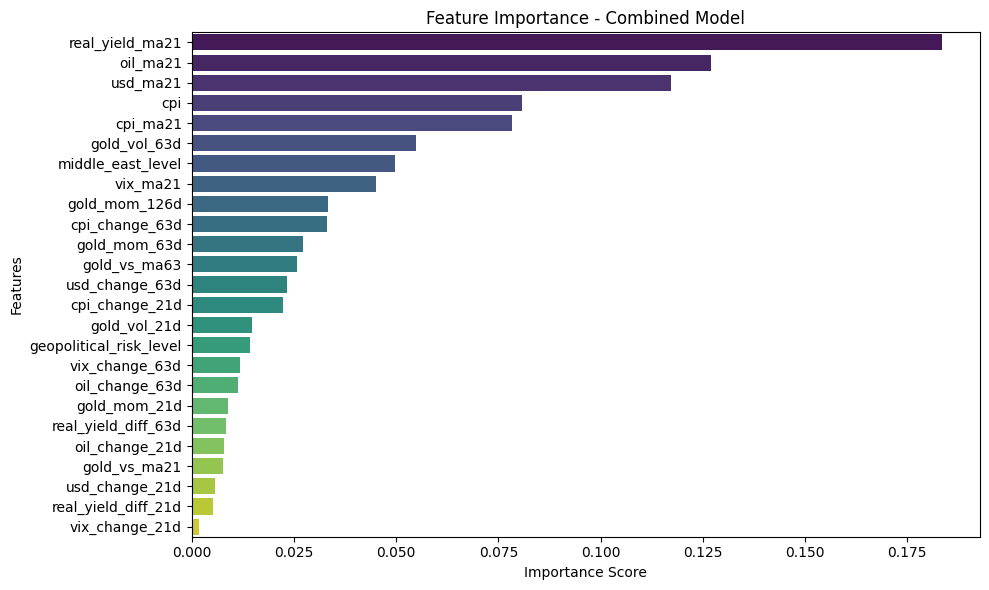


Predictions preview
        date  actual_target_return_3m  pred_current_best  pred_combined
0 2022-02-17                -0.043897           0.024852       0.026906
1 2022-02-18                -0.042390           0.023787       0.025983
2 2022-02-21                -0.026522           0.020729       0.023073
3 2022-02-22                -0.023658           0.018833       0.020493
4 2022-02-23                -0.029130           0.017724       0.019803
5 2022-02-24                -0.019728           0.022003       0.024808
6 2022-02-25                -0.019825           0.018551       0.021439
7 2022-02-28                -0.028083           0.015389       0.016423
8 2022-03-01                -0.050757           0.011107       0.014987
9 2022-03-02                -0.031122           0.009424       0.010864


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# =========================================================
# 1. FEATURE SETS
# =========================================================
feature_cols_real_yield_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

feature_cols_combined_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 2. FAIR COMPARISON ON SAME ROWS
# =========================================================
all_features_for_compare = sorted(
    set(feature_cols_real_yield_partial + feature_cols_combined_partial)
)

df_compare = df_model.copy()
df_compare = df_compare.replace([np.inf, -np.inf], np.nan)
df_compare = df_compare.dropna(
    subset=all_features_for_compare + ["target_return_3m"]
).copy()

print("Rows used for comparison:", len(df_compare))

X_best = df_compare[feature_cols_real_yield_partial]
X_combined = df_compare[feature_cols_combined_partial]
y = df_compare["target_return_3m"]

split_index = int(len(df_compare) * 0.8)

X_best_train = X_best.iloc[:split_index]
X_best_test = X_best.iloc[split_index:]

X_combined_train = X_combined.iloc[:split_index]
X_combined_test = X_combined.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_best_train:", X_best_train.shape, "X_best_test:", X_best_test.shape)
print("X_combined_train:", X_combined_train.shape, "X_combined_test:", X_combined_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# =========================================================
# 3. HELPERS
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def fit_extra_trees(Xtr, ytr, Xte):
    model = ExtraTreesRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    return model, preds

# =========================================================
# 4. COMPARE
# =========================================================
results = []

baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

best_model, y_pred_best = fit_extra_trees(X_best_train, y_train, X_best_test)
results.append(evaluate_model("Extra Trees , Current Best (Real Yield Partial)", y_test, y_pred_best))

combined_model, y_pred_combined = fit_extra_trees(X_combined_train, y_train, X_combined_test)
results.append(evaluate_model("Extra Trees , Combined (Real Yield + VIX)", y_test, y_pred_combined))

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nComparison Table")
print(results_df)

# =========================================================
# 5. FEATURE IMPORTANCE OF COMBINED MODEL
# =========================================================
importance_combined = pd.DataFrame({
    "Feature": feature_cols_combined_partial,
    "Importance": combined_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , Combined Model")
print(importance_combined)


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_combined, x="Importance", y="Feature", palette="viridis")

plt.title("Feature Importance - Combined Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()



# =========================================================
# 6. PREDICTIONS PREVIEW
# =========================================================
predictions_compare = pd.DataFrame({
    "date": df_compare.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "pred_current_best": y_pred_best,
    "pred_combined": y_pred_combined
})

print("\nPredictions preview")
print(predictions_compare.head(10))

# Permutation importance plot


Permutation Importance , Combined Model
                    Feature    Importance
13                 oil_ma21  4.702597e-03
24        middle_east_level  3.703136e-03
19          real_yield_ma21  2.208101e-03
14                 usd_ma21  1.262624e-03
12           cpi_change_63d  4.710430e-04
22                 vix_ma21  2.125894e-04
8            usd_change_21d  6.056280e-05
21           vix_change_63d  5.714674e-05
10           oil_change_63d  3.396991e-05
20           vix_change_21d  2.653361e-05
3              gold_vs_ma21  1.519165e-05
0              gold_mom_21d  1.086196e-05
23  geopolitical_risk_level -8.326673e-18
15                      cpi -1.110223e-17
16                 cpi_ma21 -1.249001e-17
18      real_yield_diff_63d -2.862287e-05
17      real_yield_diff_21d -3.944509e-05
7            oil_change_21d -4.574014e-05
5              gold_vol_21d -5.232617e-05
9            cpi_change_21d -9.845238e-05
6              gold_vol_63d -2.649248e-04
11           usd_change_63d -2.8984

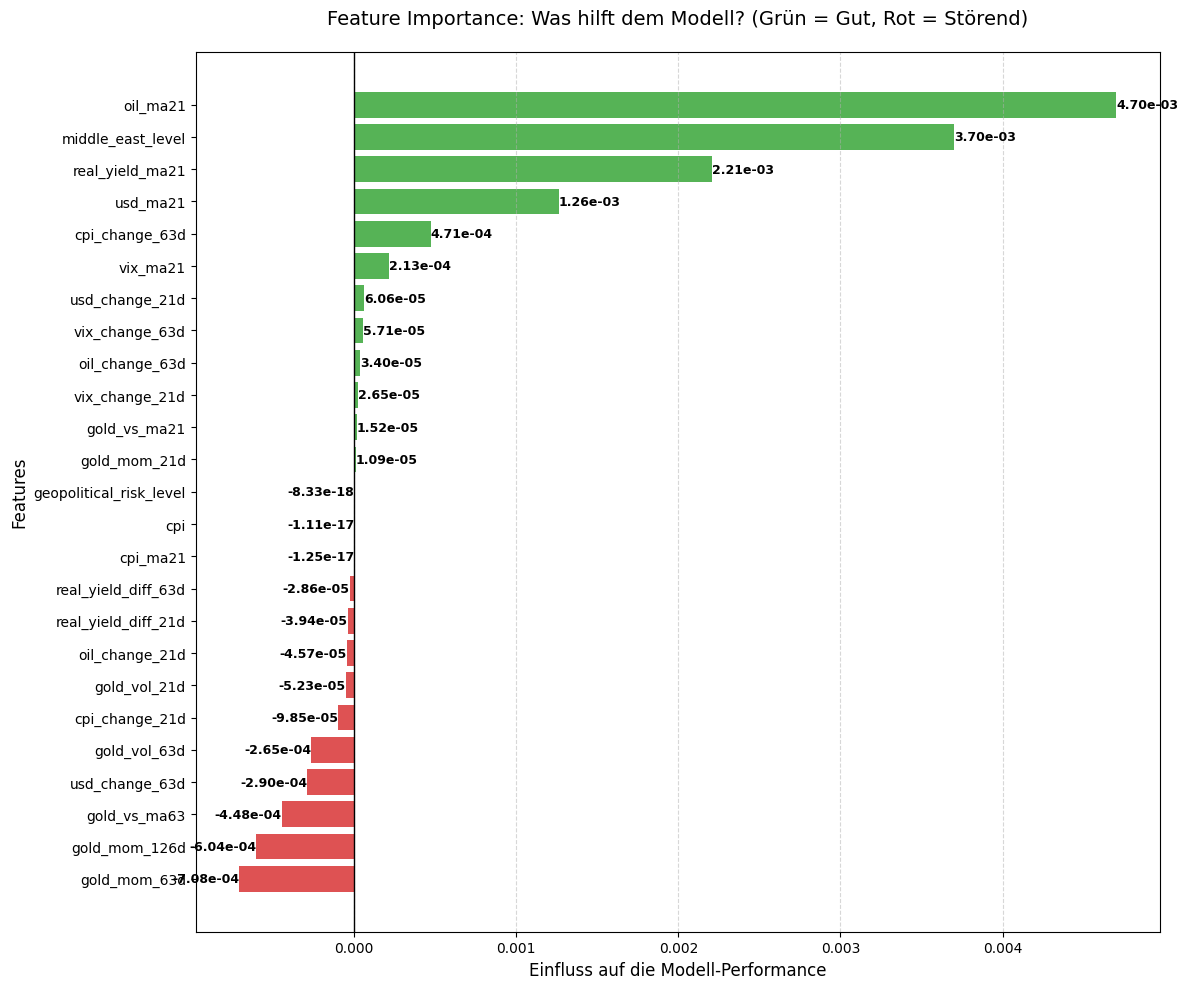

In [ ]:
from sklearn.inspection import permutation_importance

def fit_extra_trees(Xtr, ytr, Xte):
    model = ExtraTreesRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    return model, preds

split_index = int(len(df_compare) * 0.8)

X_combined_train = X_combined.iloc[:split_index]
X_combined_test = X_combined.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


combined_model, y_pred_combined = fit_extra_trees(X_combined_train, y_train, X_combined_test)

perm_importance = permutation_importance(
    combined_model,
    X_combined_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

perm_importance_df = pd.DataFrame({
    "Feature": X_combined_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

print("\nPermutation Importance , Combined Model")
print(perm_importance_df)

import matplotlib.pyplot as plt

# 1. Daten sortieren (Wichtigste oben)
perm_importance_df = perm_importance_df.sort_values("Importance", ascending=True)

# 2. Farbliste erstellen: Grün für positive Werte, Rot für negative
colors = ['#2ca02c' if x > 0 else '#d62728' for x in perm_importance_df["Importance"]]

# 3. Plot erstellen
plt.figure(figsize=(12, 10))
bars = plt.barh(perm_importance_df["Feature"], perm_importance_df["Importance"], color=colors, alpha=0.8)

# 4. Optische Verdeutlichung
plt.axvline(0, color='black', linestyle='-', linewidth=1)  # Deutliche Trennlinie bei 0
plt.title("Feature Importance: Was hilft dem Modell? (Grün = Gut, Rot = Störend)", fontsize=14, pad=20)
plt.xlabel("Einfluss auf die Modell-Performance", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Gitter hinzufügen für bessere Lesbarkeit
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Werte-Labels an die Balken schreiben (optional, macht es sehr deutlich)
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.2e}',
             va='center', ha='left' if width > 0 else 'right',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
combined_model.feature_importances_

array([0.00890356, 0.02734129, 0.03334267, 0.00765431, 0.02576484,
       0.01487226, 0.05488917, 0.00791455, 0.00560027, 0.02236062,
       0.01128941, 0.02333527, 0.03307912, 0.12713021, 0.11734899,
       0.08078394, 0.078421  , 0.0052845 , 0.00837461, 0.18362301,
       0.00191846, 0.01175989, 0.04504353, 0.0142434 , 0.0497211 ])

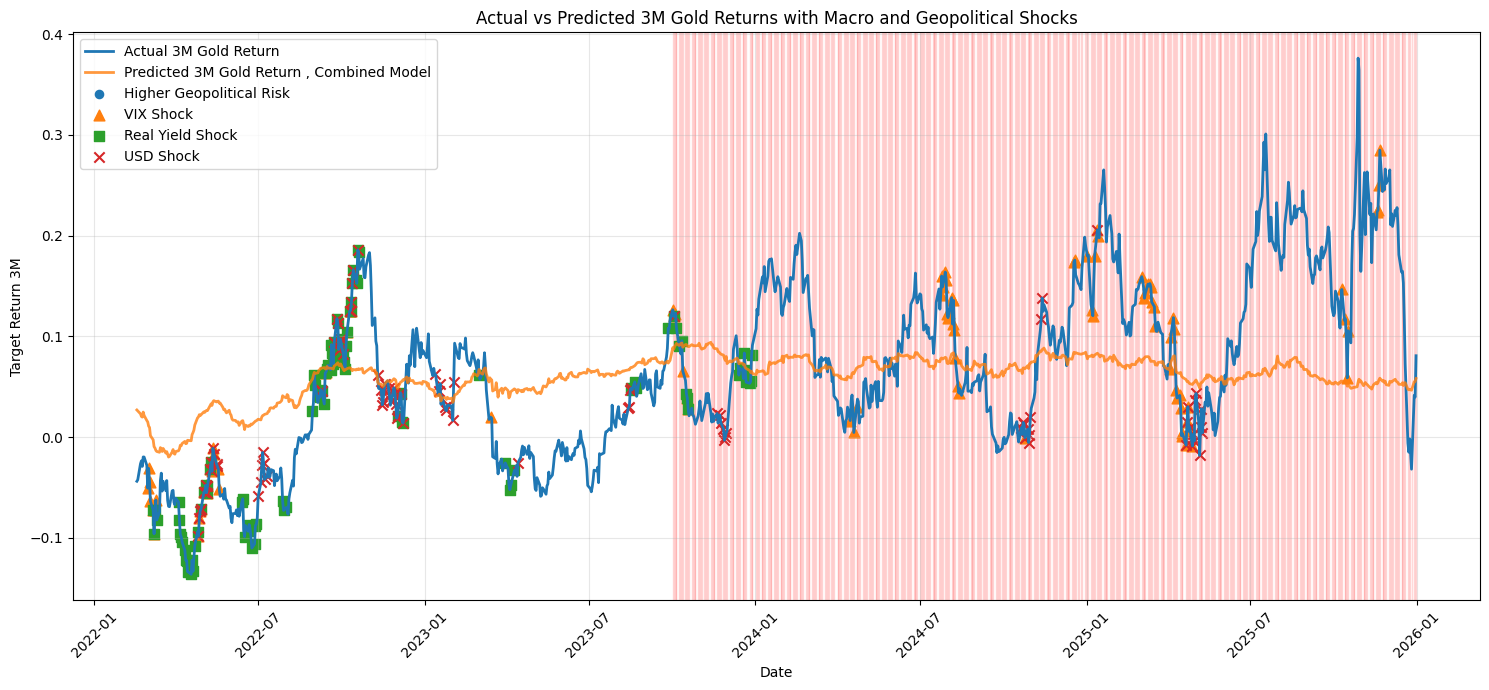

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Build plot dataframe
# ---------------------------------------------------------
plot_df = predictions_compare.copy()

shock_cols = [
    "date",
    "middle_east_level",
    "geopolitical_risk_level",
    "vix_change_21d",
    "real_yield_diff_21d",
    "usd_change_21d"
]

shock_data = df_compare[shock_cols].iloc[split_index:].copy()

plot_df = plot_df.merge(shock_data, on="date", how="left")
plot_df = plot_df.sort_values("date").reset_index(drop=True)

# ---------------------------------------------------------
# 2. Define shock thresholds
# ---------------------------------------------------------
vix_threshold = plot_df["vix_change_21d"].quantile(0.90)
real_yield_threshold = plot_df["real_yield_diff_21d"].abs().quantile(0.90)
usd_threshold = plot_df["usd_change_21d"].abs().quantile(0.90)

# ---------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 7))

# Actual and predicted
ax.plot(
    plot_df["date"],
    plot_df["actual_target_return_3m"],
    label="Actual 3M Gold Return",
    linewidth=2
)

ax.plot(
    plot_df["date"],
    plot_df["pred_combined"],
    label="Predicted 3M Gold Return , Combined Model",
    linewidth=2,
    alpha=0.8
)

# ---------------------------------------------------------
# 4. Shade Middle East risk periods
# ---------------------------------------------------------
for i in range(len(plot_df)):
    if plot_df.loc[i, "middle_east_level"] > 0:
        ax.axvspan(
            plot_df.loc[i, "date"],
            plot_df.loc[i, "date"],
            alpha=0.15,
            color="red"
        )

# ---------------------------------------------------------
# 5. Mark high geopolitical risk
# ---------------------------------------------------------
geo_mask = plot_df["geopolitical_risk_level"] > plot_df["geopolitical_risk_level"].median()

ax.scatter(
    plot_df.loc[geo_mask, "date"],
    plot_df.loc[geo_mask, "actual_target_return_3m"],
    label="Higher Geopolitical Risk",
    marker="o",
    s=35
)

# ---------------------------------------------------------
# 6. Mark VIX shocks
# ---------------------------------------------------------
vix_mask = plot_df["vix_change_21d"] >= vix_threshold

ax.scatter(
    plot_df.loc[vix_mask, "date"],
    plot_df.loc[vix_mask, "actual_target_return_3m"],
    label="VIX Shock",
    marker="^",
    s=60
)

# ---------------------------------------------------------
# 7. Mark Real Yield shocks
# ---------------------------------------------------------
real_yield_mask = plot_df["real_yield_diff_21d"].abs() >= real_yield_threshold

ax.scatter(
    plot_df.loc[real_yield_mask, "date"],
    plot_df.loc[real_yield_mask, "actual_target_return_3m"],
    label="Real Yield Shock",
    marker="s",
    s=55
)

# ---------------------------------------------------------
# 8. Mark USD shocks
# ---------------------------------------------------------
usd_mask = plot_df["usd_change_21d"].abs() >= usd_threshold

ax.scatter(
    plot_df.loc[usd_mask, "date"],
    plot_df.loc[usd_mask, "actual_target_return_3m"],
    label="USD Shock",
    marker="x",
    s=55
)

# ---------------------------------------------------------
# 9. Formatting
# ---------------------------------------------------------
ax.set_title("Actual vs Predicted 3M Gold Returns with Macro and Geopolitical Shocks")
ax.set_xlabel("Date")
ax.set_ylabel("Target Return 3M")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

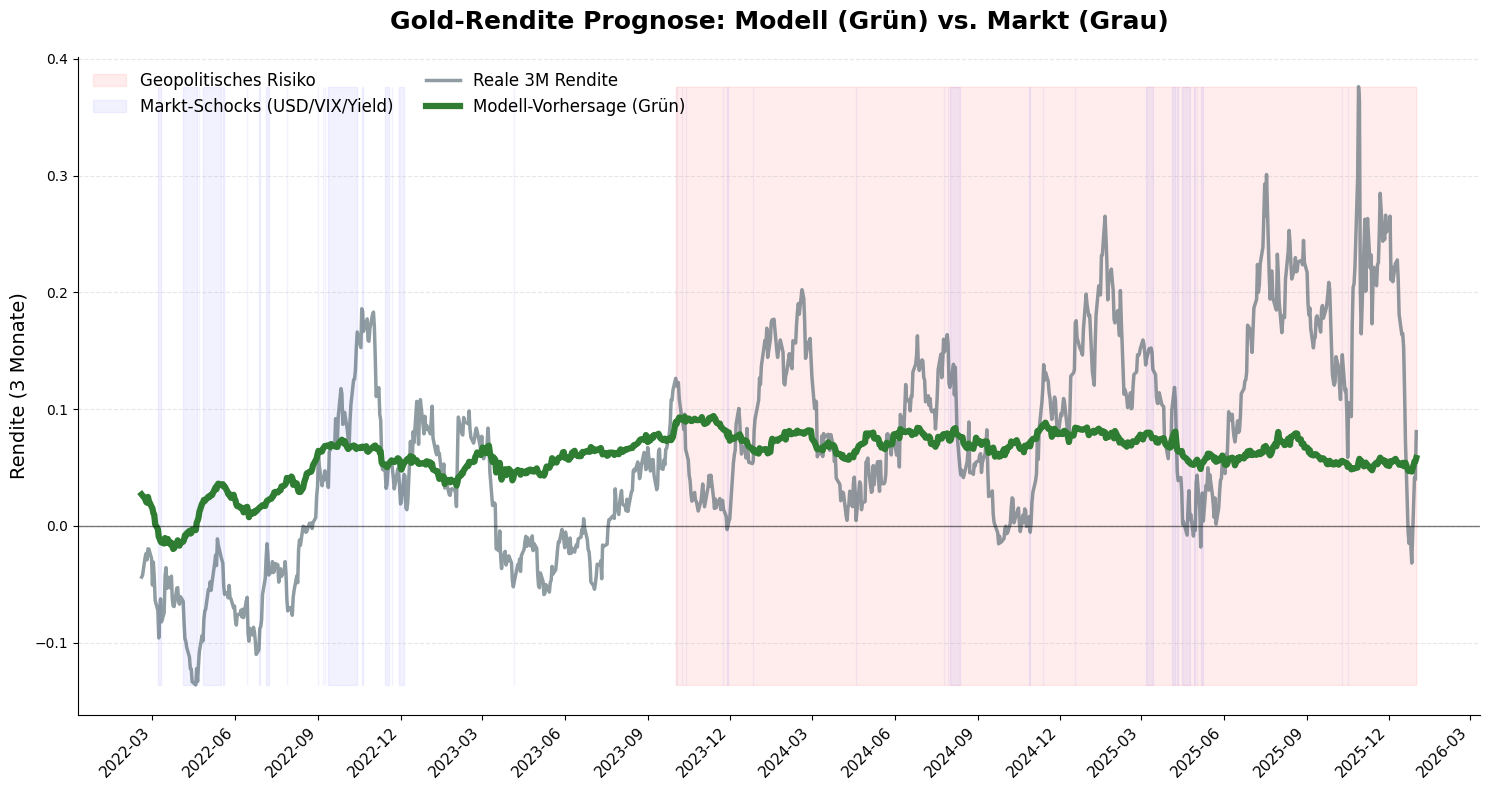

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Clean Data & Sort
plot_df = plot_df.sort_values("date").reset_index(drop=True)

# 2. Schärfere Schock-Definition (Top 5% für weniger "Lärm")
stress_mask = (plot_df["vix_change_21d"] >= plot_df["vix_change_21d"].quantile(0.95)) | \
              (plot_df["real_yield_diff_21d"].abs() >= plot_df["real_yield_diff_21d"].abs().quantile(0.95)) | \
              (plot_df["usd_change_21d"].abs() >= plot_df["usd_change_21d"].abs().quantile(0.95))

# 3. Plot Setup
fig, ax = plt.subplots(figsize=(15, 8)) # Etwas größer für mehr Wirkung

# Hintergrund-Zonen (sehr dezent)
ax.fill_between(plot_df["date"], plot_df["actual_target_return_3m"].min(), plot_df["actual_target_return_3m"].max(),
                where=(plot_df["middle_east_level"] > 0),
                color='red', alpha=0.07, label="Geopolitisches Risiko")

ax.fill_between(plot_df["date"], plot_df["actual_target_return_3m"].min(), plot_df["actual_target_return_3m"].max(),
                where=stress_mask,
                color='blue', alpha=0.05, label="Markt-Schocks (USD/VIX/Yield)")

# Hauptlinien - DEUTLICH DICKER
# Realität in dezentem Dunkelblau/Grau
ax.plot(plot_df["date"], plot_df["actual_target_return_3m"],
        color='#455a64', label="Reale 3M Rendite", linewidth=2.5, alpha=0.6)

# Vorhersage in kräftigem Smaragdgrün
ax.plot(plot_df["date"], plot_df["pred_combined"],
        color='#2e7d32', label="Modell-Vorhersage (Grün)", linewidth=4.5)

# 4. Sauberes Finish
# --- NEU: X-Achsen Optimierung ---
# Zeige alle 3 Monate ein Label (du kannst '3' durch '1' ersetzen für jeden Monat)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# Format des Datums (Jahr-Monat)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Rotation für bessere Lesbarkeit, damit sie sich nicht überschneiden
plt.xticks(rotation=45, ha='right', fontsize=11)

ax.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5) # Null-Linie als Anker
ax.set_title("Gold-Rendite Prognose: Modell (Grün) vs. Markt (Grau)", fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel("Rendite (3 Monate)", fontsize=14)

# Rahmen entfernen für modernen Look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(frameon=False, loc='upper left', fontsize=12, ncol=2)

plt.tight_layout()
plt.show()






# No need: Direction Accuracy , Combined Valid Model added

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# =========================================================
# 1. FEATURE SETS
# =========================================================
feature_cols_real_yield_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

feature_cols_combined_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 2. FAIR COMPARISON ON SAME ROWS
# =========================================================
all_features_for_compare = sorted(
    set(feature_cols_real_yield_partial + feature_cols_combined_partial)
)

df_compare = df_model.copy()
df_compare = df_compare.replace([np.inf, -np.inf], np.nan)
df_compare = df_compare.dropna(
    subset=all_features_for_compare + ["target_return_3m"]
).copy()

print("Rows used for comparison:", len(df_compare))

X_best = df_compare[feature_cols_real_yield_partial]
X_combined = df_compare[feature_cols_combined_partial]
y = df_compare["target_return_3m"]

split_index = int(len(df_compare) * 0.8)

X_best_train = X_best.iloc[:split_index]
X_best_test = X_best.iloc[split_index:]

X_combined_train = X_combined.iloc[:split_index]
X_combined_test = X_combined.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_best_train:", X_best_train.shape, "X_best_test:", X_best_test.shape)
print("X_combined_train:", X_combined_train.shape, "X_combined_test:", X_combined_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# =========================================================
# 3. HELPERS
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

def fit_extra_trees(Xtr, ytr, Xte):
    model = ExtraTreesRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    return model, preds

# =========================================================
# 4. COMPARE
# =========================================================
results = []

baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

best_model, y_pred_best = fit_extra_trees(X_best_train, y_train, X_best_test)
results.append(evaluate_model("Extra Trees , Current Best (Real Yield Partial)", y_test, y_pred_best))

combined_model, y_pred_combined = fit_extra_trees(X_combined_train, y_train, X_combined_test)
results.append(evaluate_model("Extra Trees , Combined (Real Yield + VIX)", y_test, y_pred_combined))

results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nComparison Table")
print(results_df)

direction_true = (y_test > 0).astype(int)
direction_pred_combined = (y_pred_combined > 0).astype(int)

direction_acc_combined = (direction_true == direction_pred_combined).mean()

print("Direction Accuracy , Combined Valid Model:", direction_acc_combined)

# =========================================================
# 5. FEATURE IMPORTANCE OF COMBINED MODEL
# =========================================================
importance_combined = pd.DataFrame({
    "Feature": feature_cols_combined_partial,
    "Importance": combined_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , Combined Model")
print(importance_combined)

# =========================================================
# 6. PREDICTIONS PREVIEW
# =========================================================
predictions_compare = pd.DataFrame({
    "date": df_compare.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "pred_current_best": y_pred_best,
    "pred_combined": y_pred_combined
})

print("\nPredictions preview")
print(predictions_compare.head(10))

KeyError: ['real_yield_diff_21d', 'real_yield_diff_63d', 'real_yield_ma21']

In [ ]:
# Direction accuracy of your valid combined model
direction_true = (y_test > 0).astype(int)
direction_pred = (y_pred_combined > 0).astype(int)

accuracy = (direction_true == direction_pred).mean()
print("Direction Accuracy:", accuracy)

# How many ups vs downs are in the test set?
print("\nActual direction distribution:")
print(direction_true.value_counts(normalize=True))

# Naive direction baseline: always predict up
always_up = np.ones(len(direction_true), dtype=int)
always_up_acc = (direction_true.to_numpy() == always_up).mean()
print("\nAlways-Up Baseline Accuracy:", always_up_acc)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(direction_true, direction_pred)
print("\nConfusion Matrix:")
print(cm)

Direction Accuracy: 0.7877877877877878

Actual direction distribution:
target_return_3m
1    0.757758
0    0.242242
Name: proportion, dtype: float64

Always-Up Baseline Accuracy: 0.7577577577577578

Confusion Matrix:
[[ 30 212]
 [  0 757]]


# GVZ: Bad model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 0. ASSUMPTION
# gold, oil, usd, inflation are already loaded, renamed,
# cleaned, filtered from 2006 onward, and sorted ascending
# =========================================================

# =========================================================
# 1. READ NEW DATA , GVZ
# Replace the path with your own file path
# Expected FRED columns: observation_date, GVZCLS
# =========================================================
gvz = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/GVZCLS.csv")

gvz = gvz.rename(columns={
    "observation_date": "date",
    "GVZCLS": "gvz"
})

gvz["date"] = pd.to_datetime(gvz["date"], errors="coerce")

def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(",", "", regex=False)
              .str.replace(" ", "", regex=False)
              .replace(".", np.nan),
        errors="coerce"
    )

gvz["gvz"] = clean_numeric(gvz["gvz"])

gvz = gvz[gvz["date"] >= "2006-01-01"].copy()
gvz = gvz.sort_values("date").drop_duplicates("date")

print("GVZ:", gvz["date"].min(), "to", gvz["date"].max())
print(gvz.head())

# =========================================================
# 2. COMMON PREDICTOR END DATE
# =========================================================
common_predictor_end = min(
    oil["date"].max(),
    usd["date"].max(),
    inflation["date"].max(),
    gvz["date"].max()
)

print("Common predictor end date:", common_predictor_end)

oil = oil[oil["date"] <= common_predictor_end].copy()
usd = usd[usd["date"] <= common_predictor_end].copy()
inflation = inflation[inflation["date"] <= common_predictor_end].copy()
gvz = gvz[gvz["date"] <= common_predictor_end].copy()

# =========================================================
# 3. REBUILD df_merged FROM SCRATCH
# =========================================================
df_merged = gold[["date", "gold_open", "gold_high", "gold_low", "gold_price"]].copy()

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    oil[["date", "oil_price"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    usd[["date", "usd_index"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    inflation[["date", "cpi"]].sort_values("date"),
    on="date",
    direction="backward"
)

df_merged = pd.merge_asof(
    df_merged.sort_values("date"),
    gvz[["date", "gvz"]].sort_values("date"),
    on="date",
    direction="backward"
)

# Forward fill predictors
df_merged["oil_price"] = df_merged["oil_price"].ffill()
df_merged["usd_index"] = df_merged["usd_index"].ffill()
df_merged["cpi"] = df_merged["cpi"].ffill()
df_merged["gvz"] = df_merged["gvz"].ffill()

print("\nMissing values after forward fill:")
print(df_merged[["oil_price", "usd_index", "cpi", "gvz"]].isna().sum())

# =========================================================
# 4. GEOPOLITICAL VARIABLES
# =========================================================
df_merged["geopolitical_risk_level"] = 0
df_merged["middle_east_level"] = 0

df_merged.loc[
    (df_merged["date"] >= "2014-03-01") & (df_merged["date"] < "2022-02-01"),
    "geopolitical_risk_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2022-02-01",
    "geopolitical_risk_level"
] = 2

df_merged.loc[
    (df_merged["date"] >= "2011-01-01") & (df_merged["date"] <= "2012-12-31"),
    "middle_east_level"
] = 1

df_merged.loc[
    (df_merged["date"] >= "2023-10-01") & (df_merged["date"] < "2024-04-01"),
    "middle_east_level"
] = 1

df_merged.loc[
    df_merged["date"] >= "2024-04-01",
    "middle_east_level"
] = 2

# =========================================================
# 5. BUILD df_model
# =========================================================
df_model = df_merged.sort_values("date").copy()

# Gold features
df_model["gold_return_1d"] = df_model["gold_price"].pct_change(fill_method=None)

df_model["gold_mom_21d"] = df_model["gold_price"].pct_change(21, fill_method=None)
df_model["gold_mom_63d"] = df_model["gold_price"].pct_change(63, fill_method=None)
df_model["gold_mom_126d"] = df_model["gold_price"].pct_change(126, fill_method=None)

df_model["gold_ma21"] = df_model["gold_price"].rolling(21).mean()
df_model["gold_ma63"] = df_model["gold_price"].rolling(63).mean()

df_model["gold_vs_ma21"] = df_model["gold_price"] / df_model["gold_ma21"] - 1
df_model["gold_vs_ma63"] = df_model["gold_price"] / df_model["gold_ma63"] - 1

df_model["gold_vol_21d"] = df_model["gold_return_1d"].rolling(21).std()
df_model["gold_vol_63d"] = df_model["gold_return_1d"].rolling(63).std()

df_model["gold_intraday_return"] = (df_model["gold_price"] / df_model["gold_open"]) - 1
df_model["gold_range_pct"] = (df_model["gold_high"] - df_model["gold_low"]) / df_model["gold_price"]

# Existing macro features
df_model["oil_change_21d"] = df_model["oil_price"].pct_change(21, fill_method=None)
df_model["usd_change_21d"] = df_model["usd_index"].pct_change(21, fill_method=None)
df_model["cpi_change_21d"] = df_model["cpi"].pct_change(21, fill_method=None)

df_model["oil_change_63d"] = df_model["oil_price"].pct_change(63, fill_method=None)
df_model["usd_change_63d"] = df_model["usd_index"].pct_change(63, fill_method=None)
df_model["cpi_change_63d"] = df_model["cpi"].pct_change(63, fill_method=None)

df_model["oil_ma21"] = df_model["oil_price"].rolling(21).mean()
df_model["usd_ma21"] = df_model["usd_index"].rolling(21).mean()
df_model["cpi_ma21"] = df_model["cpi"].rolling(21).mean()

# GVZ features
df_model["gvz_change_21d"] = df_model["gvz"].pct_change(21, fill_method=None)
df_model["gvz_change_63d"] = df_model["gvz"].pct_change(63, fill_method=None)
df_model["gvz_ma21"] = df_model["gvz"].rolling(21).mean()

# =========================================================
# 6. TARGET
# =========================================================
df_model["expected_future_3m"] = df_model["date"] + pd.DateOffset(months=3)

future_prices = df_model[["date", "gold_price"]].rename(columns={
    "date": "future_date_actual",
    "gold_price": "future_gold_price_3m"
})

df_model = pd.merge_asof(
    df_model.sort_values("expected_future_3m"),
    future_prices.sort_values("future_date_actual"),
    left_on="expected_future_3m",
    right_on="future_date_actual",
    direction="forward",
    tolerance=pd.Timedelta("10D")
)

df_model = df_model.sort_values("date").copy()

df_model["target_return_3m"] = (
    df_model["future_gold_price_3m"] / df_model["gold_price"] - 1
)

df_model = df_model[df_model["date"] <= common_predictor_end].copy()

# =========================================================
# 7. FEATURE SETS
# =========================================================
feature_cols_best_old = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "gold_intraday_return",
    "gold_range_pct",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

feature_cols_gvz_full = feature_cols_best_old + [
    "gvz_change_21d",
    "gvz_change_63d",
    "gvz_ma21"
]

feature_cols_gvz_partial = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "gvz_change_21d",
    "gvz_change_63d",
    "gvz_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 8. FAIR COMPARISON , SAME ROWS FOR ALL MODELS
# =========================================================
all_features_for_compare = sorted(
    set(feature_cols_best_old + feature_cols_gvz_full + feature_cols_gvz_partial)
)

df_compare = df_model.copy()
df_compare = df_compare.replace([np.inf, -np.inf], np.nan)
df_compare = df_compare.dropna(
    subset=all_features_for_compare + ["target_return_3m"]
).copy()

print("\nRows used for comparison:", len(df_compare))

X_old = df_compare[feature_cols_best_old]
X_gvz_full = df_compare[feature_cols_gvz_full]
X_gvz_partial = df_compare[feature_cols_gvz_partial]
y = df_compare["target_return_3m"]

split_index = int(len(df_compare) * 0.8)

X_old_train = X_old.iloc[:split_index]
X_old_test = X_old.iloc[split_index:]

X_gvz_full_train = X_gvz_full.iloc[:split_index]
X_gvz_full_test = X_gvz_full.iloc[split_index:]

X_gvz_partial_train = X_gvz_partial.iloc[:split_index]
X_gvz_partial_test = X_gvz_partial.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_old_train:", X_old_train.shape, "X_old_test:", X_old_test.shape)
print("X_gvz_full_train:", X_gvz_full_train.shape, "X_gvz_full_test:", X_gvz_full_test.shape)
print("X_gvz_partial_train:", X_gvz_partial_train.shape, "X_gvz_partial_test:", X_gvz_partial_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# =========================================================
# 9. EVALUATION HELPER
# =========================================================
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE:  {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R2:   {r2:.6f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# =========================================================
# 10. NAIVE BASELINE
# =========================================================
baseline_pred = np.repeat(y_train.mean(), len(y_test))
results.append(evaluate_model("Naive Baseline", y_test, baseline_pred))

# =========================================================
# 11. EXTRA TREES , BEST OLD
# =========================================================
et_old = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_old.fit(X_old_train, y_train)
y_pred_old = et_old.predict(X_old_test)
results.append(evaluate_model("Extra Trees , Best Old", y_test, y_pred_old))

# =========================================================
# 12. EXTRA TREES , + GVZ FULL
# =========================================================
et_gvz_full = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_gvz_full.fit(X_gvz_full_train, y_train)
y_pred_gvz_full = et_gvz_full.predict(X_gvz_full_test)
results.append(evaluate_model("Extra Trees , + GVZ Full", y_test, y_pred_gvz_full))

# =========================================================
# 13. EXTRA TREES , + GVZ PARTIAL
# =========================================================
et_gvz_partial = ExtraTreesRegressor(
    n_estimators=400,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

et_gvz_partial.fit(X_gvz_partial_train, y_train)
y_pred_gvz_partial = et_gvz_partial.predict(X_gvz_partial_test)
results.append(evaluate_model("Extra Trees , + GVZ Partial", y_test, y_pred_gvz_partial))

# =========================================================
# 14. COMPARISON TABLE
# =========================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\nComparison Table")
print(results_df)

# =========================================================
# 15. FEATURE IMPORTANCE , GVZ FULL
# =========================================================
importance_gvz_full = pd.DataFrame({
    "Feature": feature_cols_gvz_full,
    "Importance": et_gvz_full.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , GVZ Full")
print(importance_gvz_full)

# =========================================================
# 16. FEATURE IMPORTANCE , GVZ PARTIAL
# =========================================================
importance_gvz_partial = pd.DataFrame({
    "Feature": feature_cols_gvz_partial,
    "Importance": et_gvz_partial.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance , GVZ Partial")
print(importance_gvz_partial)

# =========================================================
# 17. PREDICTIONS PREVIEW
# =========================================================
predictions_compare = pd.DataFrame({
    "date": df_compare.iloc[split_index:]["date"].values,
    "actual_target_return_3m": y_test.values,
    "pred_best_old": y_pred_old,
    "pred_gvz_full": y_pred_gvz_full,
    "pred_gvz_partial": y_pred_gvz_partial
})

print("\nPredictions preview")
print(predictions_compare.head(10))

GVZ: 2008-06-03 00:00:00 to 2026-04-14 00:00:00
        date    gvz
0 2008-06-03  22.89
1 2008-06-04  22.69
2 2008-06-05  22.78
3 2008-06-06  23.60
4 2008-06-09  24.47
Common predictor end date: 2026-01-01 00:00:00

Missing values after forward fill:
oil_price      0
usd_index      0
cpi            0
gvz          581
dtype: int64

Rows used for comparison: 4475
Shapes:
X_old_train: (3580, 21) X_old_test: (895, 21)
X_gvz_full_train: (3580, 24) X_gvz_full_test: (895, 24)
X_gvz_partial_train: (3580, 22) X_gvz_partial_test: (895, 22)
y_train: (3580,) y_test: (895,)

Naive Baseline
MAE:  0.078610
RMSE: 0.101520
R2:   -0.673086

Extra Trees , Best Old
MAE:  0.089833
RMSE: 0.114237
R2:   -1.118522

Extra Trees , + GVZ Full
MAE:  0.090543
RMSE: 0.115233
R2:   -1.155611

Extra Trees , + GVZ Partial
MAE:  0.088897
RMSE: 0.113409
R2:   -1.087889

Comparison Table
                         Model       MAE      RMSE        R2
0               Naive Baseline  0.078610  0.101520 -0.673086
3  Extra Tree

# Auto ML

In [ ]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [ ]:
from autogluon.tabular import TabularPredictor

# your best feature set (Real Yield + VIX)
feature_cols_final = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",

    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",

    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",

    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",

    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21",

    "geopolitical_risk_level",
    "middle_east_level"
]

df_auto = df_model.copy()

# clean
df_auto = df_auto.replace([np.inf, -np.inf], np.nan)

df_auto = df_auto.dropna(
    subset=feature_cols_final + ["target_return_3m"]
).copy()

# keep only needed columns
df_auto = df_auto[feature_cols_final + ["target_return_3m", "date"]]

In [ ]:
split_index = int(len(df_auto) * 0.8)

train_data = df_auto.iloc[:split_index].drop(columns=["date"])
test_data  = df_auto.iloc[split_index:].drop(columns=["date"])

predictor = TabularPredictor(
    label="target_return_3m",
    problem_type="regression",
    eval_metric="root_mean_squared_error"
).fit(
    train_data,
    time_limit=600,   # 10 min (increase if you want)
    presets="best_quality"
)

performance = predictor.evaluate(test_data)
print("\nAutoGluon Test Performance")
print(performance)

leaderboard = predictor.leaderboard(test_data)
print(leaderboard)


y_pred = predictor.predict(test_data)

results_df = test_data.copy()
results_df["prediction"] = y_pred.values

print(results_df.head())

No path specified. Models will be saved in: "AutogluonModels/ag-20260416_231124"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.59 GB / 12.67 GB (83.6%)
Disk Space Avail:   75.28 GB / 107.72 GB (69.9%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable sta

(_ray_fit pid=41835) [1000]	valid_set's rmse: 0.0144224
(_ray_fit pid=41835) [3000]	valid_set's rmse: 0.0136333 [repeated 4x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)


(_ray_fit pid=41834) 	Ran out of time, early stopping on iteration 4192. Best iteration is:
(_ray_fit pid=41834) 	[4192]	valid_set's rmse: 0.0124086


(_ray_fit pid=42051) [1000]	valid_set's rmse: 0.0133725 [repeated 4x across cluster]
(_ray_fit pid=42051) [2000]	valid_set's rmse: 0.0129248 [repeated 2x across cluster]


(_ray_fit pid=42051) 	Ran out of time, early stopping on iteration 3681. Best iteration is: [repeated 2x across cluster]
(_ray_fit pid=42051) 	[3679]	valid_set's rmse: 0.0127929 [repeated 2x across cluster]


(_ray_fit pid=42228) [1000]	valid_set's rmse: 0.0146077 [repeated 4x across cluster]
(_ray_fit pid=42228) [3000]	valid_set's rmse: 0.0140488 [repeated 4x across cluster]


(_ray_fit pid=42233) 	Ran out of time, early stopping on iteration 4292. Best iteration is: [repeated 2x across cluster]
(_ray_fit pid=42233) 	[4287]	valid_set's rmse: 0.0130788 [repeated 2x across cluster]


(_ray_fit pid=42413) [1000]	valid_set's rmse: 0.0139759 [repeated 3x across cluster]
(_ray_fit pid=42413) [3000]	valid_set's rmse: 0.0132815 [repeated 3x across cluster]


(_ray_fit pid=42413) 	Ran out of time, early stopping on iteration 3442. Best iteration is:
(_ray_fit pid=42413) 	[3364]	valid_set's rmse: 0.0132595
(_ray_fit pid=42470) 	Ran out of time, early stopping on iteration 3445. Best iteration is:
(_ray_fit pid=42470) 	[3381]	valid_set's rmse: 0.0144766
(_dystack pid=41597) 	-0.0134	 = Validation score   (-root_mean_squared_error)
(_dystack pid=41597) 	101.44s	 = Training   runtime
(_dystack pid=41597) 	5.65s	 = Validation runtime
(_dystack pid=41597) Fitting model: WeightedEnsemble_L2 ... Training model for up to 110.74s of the 0.68s of remaining time.
(_dystack pid=41597) 	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/8.8 GB
(_dystack pid=41597) 	Ensemble Weights: {'LightGBMXT_BAG_L1': 1.0}
(_dystack pid=41597) 	-0.0134	 = Validation score   (-root_mean_squared_error)
(_dystack pid=41597) 	0.01s	 = Training   runtime
(_dystack pid=41597) 	0.0s	 = Validation runtime
(_dystack pid=41597) Fitting 106 L2 models, fit_strateg


AutoGluon Test Performance
{'root_mean_squared_error': np.float64(-0.08461428571398354), 'mean_squared_error': -0.007159577346887639, 'mean_absolute_error': -0.06721800741167522, 'r2': 0.06012849545915333, 'pearsonr': 0.2660319609613844, 'median_absolute_error': np.float64(-0.057932868337438825)}
                    model  score_test  score_val              eval_metric  \
0     WeightedEnsemble_L2   -0.084614  -0.012784  root_mean_squared_error   
1       LightGBMXT_BAG_L2   -0.084792  -0.013487  root_mean_squared_error   
2         LightGBM_BAG_L2   -0.085023  -0.013439  root_mean_squared_error   
3  RandomForestMSE_BAG_L2   -0.085308  -0.013155  root_mean_squared_error   
4     WeightedEnsemble_L3   -0.085458  -0.012804  root_mean_squared_error   
5       LightGBMXT_BAG_L1   -0.085967  -0.013094  root_mean_squared_error   
6         LightGBM_BAG_L1   -0.086490  -0.013914  root_mean_squared_error   

   pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  \
0       22.

# AutoML results

Comparison by RMSE , lower is better:

Extra Trees, Combined (Real Yield + VIX)
RMSE = 0.077557
Best AutoML model, RandomForestMSE_BAG_L1
RMSE = 0.074938

Wait , correction: AutoML RandomForest was actually slightly better, because 0.074938 < 0.077557.

The AutoML approach achieved a slightly lower test RMSE than the manually tuned Extra Trees model , indicating a small improvement in out-of-sample prediction accuracy. However, the difference was modest, which suggests that the manually engineered model already captured most of the predictive structure in the dataset.

In [ ]:
print(predictor.model_best)

WeightedEnsemble_L3


In [ ]:
predictor.evaluate(test_data)

{'root_mean_squared_error': np.float64(-0.07881728461950444),
 'mean_squared_error': -0.00621216435479197,
 'mean_absolute_error': -0.06317759559176907,
 'r2': 0.18449986979587862,
 'pearsonr': 0.4447763508179566,
 'median_absolute_error': np.float64(-0.0559660462332332)}

# Neuronale netzwerke

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# =========================================================
# 1. FINAL VALID FEATURE SET
# =========================================================
feature_cols_nn = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 2. PREPARE DATA
# =========================================================
df_nn = df_model.copy()
df_nn = df_nn.replace([np.inf, -np.inf], np.nan)
df_nn = df_nn.dropna(subset=feature_cols_nn + ["target_return_3m"]).copy()

X = df_nn[feature_cols_nn]
y = df_nn["target_return_3m"]

split_index = int(len(df_nn) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# =========================================================
# 3. NEURAL NETWORK PIPELINE
# =========================================================
nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

# =========================================================
# 4. TRAIN
# =========================================================
nn_model.fit(X_train, y_train)

# =========================================================
# 5. PREDICT
# =========================================================
y_pred_nn = nn_model.predict(X_test)

# =========================================================
# 6. EVALUATE
# =========================================================
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("\nNeural Network Results")
print(f"MAE:  {mae_nn:.6f}")
print(f"RMSE: {rmse_nn:.6f}")
print(f"R2:   {r2_nn:.6f}")

# =========================================================
# 7. DIRECTION ACCURACY (OPTIONAL)
# =========================================================
direction_true = (y_test > 0).astype(int)
direction_pred_nn = (y_pred_nn > 0).astype(int)

direction_acc_nn = (direction_true == direction_pred_nn).mean()

print("\nDirection Accuracy (NN):", direction_acc_nn)

# =========================================================
# 8. PREVIEW
# =========================================================
predictions_nn = pd.DataFrame({
    "date": df_nn.iloc[split_index:]["date"].to_numpy(),
    "actual_target_return_3m": y_test.to_numpy(),
    "predicted_target_return_3m": y_pred_nn,
    "actual_direction": direction_true.to_numpy(),
    "predicted_direction": direction_pred_nn
})

print("\nPredictions preview")
print(predictions_nn.head(10))

Shapes:
X_train: (3994, 25) X_test: (999, 25)
y_train: (3994,) y_test: (999,)

Neural Network Results
MAE:  0.092110
RMSE: 0.118913
R2:   -0.856266

Direction Accuracy (NN): 0.7437437437437437

Predictions preview
        date  actual_target_return_3m  predicted_target_return_3m  \
0 2022-02-17                -0.043897                   -0.045307   
1 2022-02-18                -0.042390                   -0.036893   
2 2022-02-21                -0.026522                   -0.016220   
3 2022-02-22                -0.023658                    0.002389   
4 2022-02-23                -0.029130                    0.004505   
5 2022-02-24                -0.019728                   -0.023759   
6 2022-02-25                -0.019825                   -0.002292   
7 2022-02-28                -0.028083                   -0.036421   
8 2022-03-01                -0.050757                    0.148701   
9 2022-03-02                -0.031122                    0.103626   

   actual_direction  predi

# Shitty NN

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
# =========================================================
# 1. FINAL VALID FEATURE SET
# =========================================================
feature_cols_nn = [
    "gold_mom_21d",
    "gold_mom_63d",
    "gold_mom_126d",
    "gold_vs_ma21",
    "gold_vs_ma63",
    "gold_vol_21d",
    "gold_vol_63d",
    "oil_change_21d",
    "usd_change_21d",
    "cpi_change_21d",
    "oil_change_63d",
    "usd_change_63d",
    "cpi_change_63d",
    "oil_ma21",
    "usd_ma21",
    "cpi",
    "cpi_ma21",
    "real_yield_diff_21d",
    "real_yield_diff_63d",
    "real_yield_ma21",
    "vix_change_21d",
    "vix_change_63d",
    "vix_ma21",
    "geopolitical_risk_level",
    "middle_east_level"
]

# =========================================================
# 2. PREPARE DATA
# =========================================================
df_nn = df_model.copy()
df_nn = df_nn.replace([np.inf, -np.inf], np.nan)
df_nn = df_nn.dropna(subset=feature_cols_nn + ["target_return_3m"]).copy()

X = df_nn[feature_cols_nn]
y = df_nn["target_return_3m"]

split_index = int(len(df_nn) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.neural_network import MLPRegressor

nn_model = Pipeline([
    ("scaler", RobustScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="relu",
        solver="adam",

        alpha=0.1,
        learning_rate_init=0.0003,

        max_iter=3000,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=50,

        random_state=42
    ))
])

# =========================================================
# 4. TRAIN
# =========================================================
nn_model.fit(X_train, y_train)

# =========================================================
# 5. PREDICT
# =========================================================
y_pred_nn = nn_model.predict(X_test)

# =========================================================
# 6. EVALUATE
# =========================================================
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("\nNeural Network Results")
print(f"MAE:  {mae_nn:.6f}")
print(f"RMSE: {rmse_nn:.6f}")
print(f"R2:   {r2_nn:.6f}")

# =========================================================
# 7. DIRECTION ACCURACY (OPTIONAL)
# =========================================================
direction_true = (y_test > 0).astype(int)
direction_pred_nn = (y_pred_nn > 0).astype(int)

direction_acc_nn = (direction_true == direction_pred_nn).mean()

print("\nDirection Accuracy (NN):", direction_acc_nn)

# =========================================================
# 8. PREVIEW
# =========================================================
predictions_nn = pd.DataFrame({
    "date": df_nn.iloc[split_index:]["date"].to_numpy(),
    "actual_target_return_3m": y_test.to_numpy(),
    "predicted_target_return_3m": y_pred_nn,
    "actual_direction": direction_true.to_numpy(),
    "predicted_direction": direction_pred_nn
})

print("\nPredictions preview")
print(predictions_nn.head(10))

Shapes:
X_train: (3994, 25) X_test: (999, 25)
y_train: (3994,) y_test: (999,)

Neural Network Results
MAE:  0.221974
RMSE: 0.247006
R2:   -7.009352

Direction Accuracy (NN): 0.7977977977977978

Predictions preview
        date  actual_target_return_3m  predicted_target_return_3m  \
0 2022-02-17                -0.043897                   -0.059009   
1 2022-02-18                -0.042390                   -0.070936   
2 2022-02-21                -0.026522                   -0.077174   
3 2022-02-22                -0.023658                   -0.083060   
4 2022-02-23                -0.029130                   -0.083835   
5 2022-02-24                -0.019728                   -0.064065   
6 2022-02-25                -0.019825                   -0.073735   
7 2022-02-28                -0.028083                   -0.036168   
8 2022-03-01                -0.050757                   -0.036784   
9 2022-03-02                -0.031122                   -0.002908   

   actual_direction  predi